# Mini Projet Prompt Engineering – AI Business Assistant

**Contexte** : une entreprise souhaite mettre en place « AI Business Assistant », un assistant IA polyvalent capable d'aider ses collaborateurs à exploiter des documents, analyser des données, faire du machine learning et produire des résultats structurés.

**LLM utilisé** : ChatGPT (interface web).

**Démarche** : pour chaque tâche demandée :
1. le **prompt** utilisé ;
2. la **capture** de la réponse de ChatGPT ;
3. les **observations**.

**Sommaire**
- Partie 1 – Anatomie d'un prompt
- Partie 2 – Comparer les techniques de prompting
- Partie 3 – Prompt Engineering et raisonnement
- Partie 4 – Sorties structurées
- Partie 5 – Prompts pour les applications métier
- Partie 6 – Prompt Engineering pour le Machine Learning
- Partie 7 – Prompt Engineering et RAG
- Partie 8 – Évaluation et optimisation des prompts
- Partie 9 – Bonus

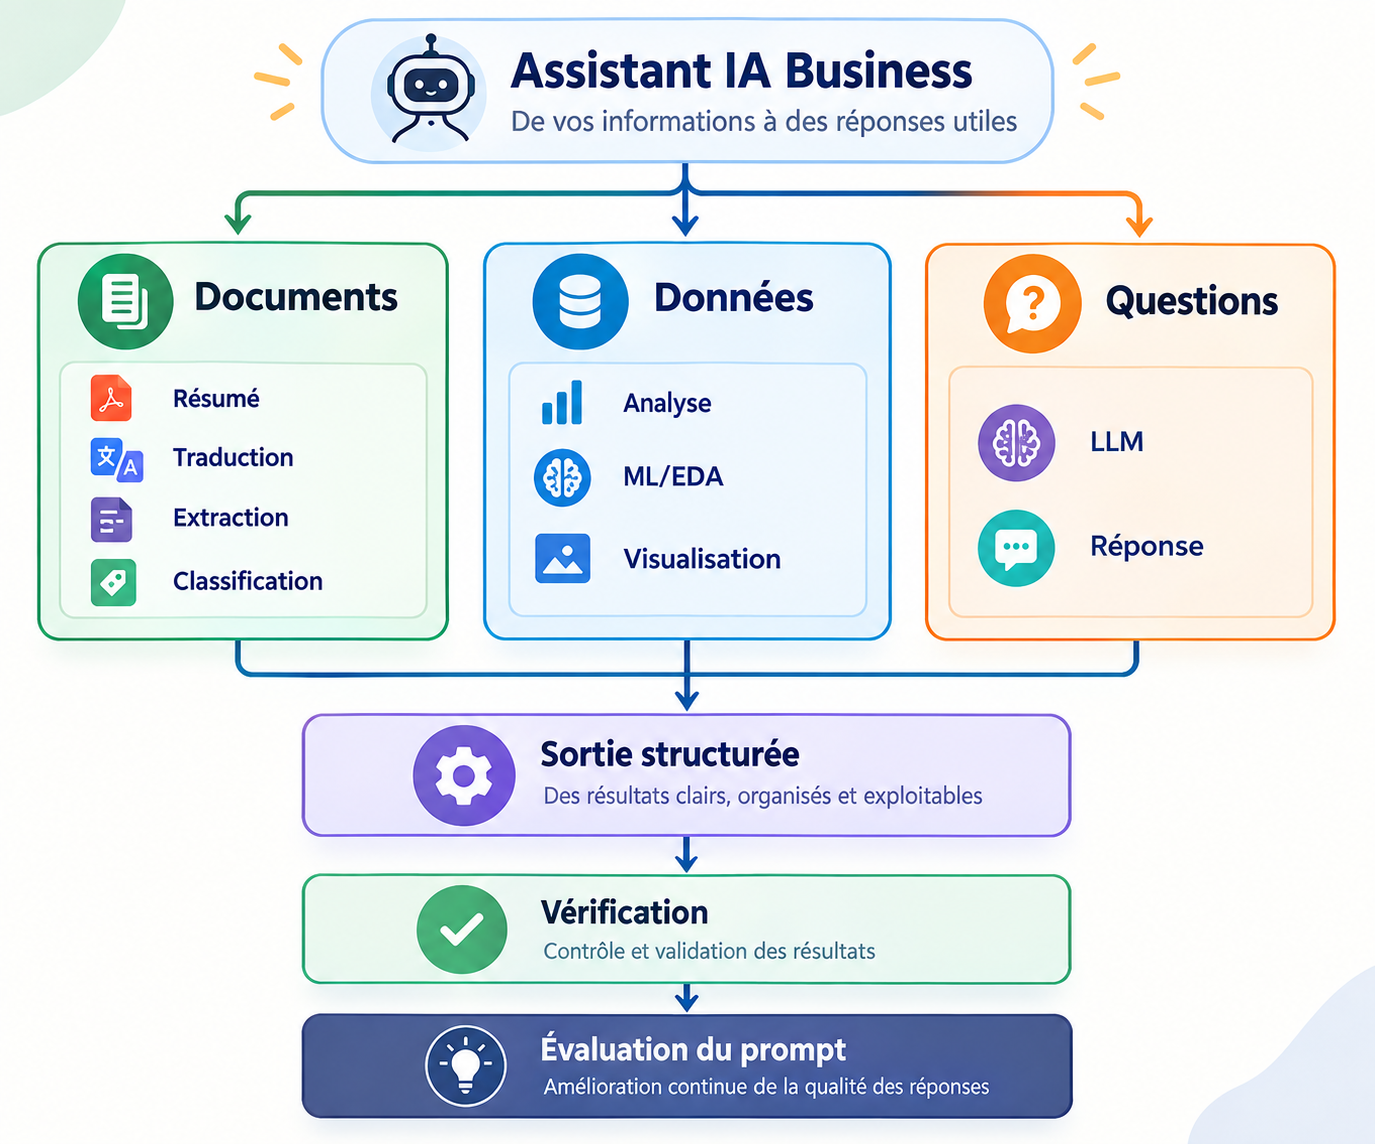

---
## Partie 1 – Anatomie d'un prompt

> **Consigne** : construire un prompt, à partir de ses différentes composantes, pour résoudre un problème comme « *Je souhaite analyser les retours de clients d'une entreprise.* »

Nous constatons que cette demande est trop vague : le modèle ne sait ni quels retours analyser, ni quel type d'analyse produire, ni pour qui, ni sous quelle forme

### Les composantes d'un prompt

| Composante | Rôle | Question à laquelle elle répond |
|---|---|---|
| **Rôle** | Fixe l'expertise et le point de vue du modèle | Qui répond ? |
| **Contexte** | Situe la demande : entreprise, enjeu, destinataire | Pourquoi et pour qui ? |
| **Tâche** | Décrit précisément le résultat attendu | Que faut-il faire ? |
| **Instructions** | Découpe le travail en étapes | Comment procéder ? |
| **Contraintes** | Pose les limites : sources, longueur, interdits | Que ne faut-il pas faire ? |
| **Format de sortie** | Impose la structure de la réponse | Sous quelle forme ? |
| **Ton** | Adapte le registre au lecteur | Comment le dire ? |
| **Données** | Fournit le contenu à traiter, entre délimiteurs | Sur quoi travailler ? |
| **Exemples** *(optionnel)* | Montre une réponse attendue | À quoi ressemble une bonne réponse ? |

## Prompt

Les avis sont ceux de **ShopNet**, une enseigne de e-commerce fictive.

```text
# RÔLE
Tu es analyste de l'expérience client, spécialisé dans le e-commerce.

# CONTEXTE
ShopNet est une enseigne de vente en ligne (site web + application mobile)
qui livre ses clients à domicile. La direction de l'expérience client veut
savoir quels problèmes corriger en priorité. Le rapport sera lu par des
managers non techniques.

# TÂCHE
Analyse les avis clients fournis entre les balises <avis> et </avis>.

# INSTRUCTIONS
1. Attribue à chaque avis un sentiment : positif, négatif ou mitigé
   (un avis mitigé contient un point positif et un point négatif).
2. Regroupe les avis par thème : livraison, application mobile, paiement,
   service client, prix, produit, emballage.
3. Classe les problèmes par priorité selon le nombre d'avis concernés,
   la gravité et le risque de perdre le client.
4. Signale les avis qui demandent une action immédiate.
5. Propose une recommandation concrète pour chaque problème prioritaire.

# CONTRAINTES
- Utilise uniquement les avis fournis et cite leurs identifiants (ex. A03)
  pour justifier chaque constat.
- N'invente aucune information. Si une cause n'est pas établie,
  présente-la comme une hypothèse.
- 400 mots maximum, tableaux non compris.

# FORMAT DE SORTIE
Réponds en Markdown avec ces sections :
1. Synthèse (3 phrases maximum)
2. Répartition des sentiments (tableau : Sentiment | Nombre | Identifiants)
3. Problèmes prioritaires (tableau : Rang | Problème | Avis concernés |
   Gravité faible/moyenne/élevée | Justification)
4. Avis à traiter immédiatement
5. Recommandations
6. Limites de l'analyse

# TON
Professionnel, factuel et direct.

# DONNÉES
<avis>
A01 : Application très pratique, je commande en 2 minutes. Livraison reçue le lendemain, parfait.
A02 : Ma commande devait arriver mardi, je l'ai reçue le samedi suivant. Personne ne m'a prévenu du retard.
A03 : L'application plante à chaque fois que je veux payer par carte. J'ai dû passer par le site.
A04 : Le conseiller a été très aimable et a résolu mon problème de remboursement en un appel.
A05 : Le service est rapide mais l'application plante régulièrement.
A06 : J'ai été débité deux fois pour la même commande (45 000 FCFA). J'attends un remboursement depuis 10 jours, sans réponse.
A07 : Produits conformes à la description, bon rapport qualité-prix.
A08 : Troisième retard de livraison ce mois-ci. Si ça continue, je vais chez un concurrent.
A09 : Colis arrivé avec l'emballage déchiré, mais le produit était intact.
A10 : Impossible de joindre le service client : 40 minutes d'attente au téléphone et aucune réponse au chat.
A11 : Depuis la dernière mise à jour, l'appli se ferme toute seule sur mon téléphone Android.
A12 : Les frais de livraison ont augmenté sans que ce soit annoncé clairement.
</avis>
```

# Partie 2 - Comparaisons des techniques de prompting

### 1. Zero-shot
*Aucun exemple : le modèle ne reçoit que la consigne.*

```text
Classe le commentaire suivant.

Commentaire : « Le service est rapide mais l'application plante régulièrement. »

Classes possibles : positif, négatif, neutre.
```

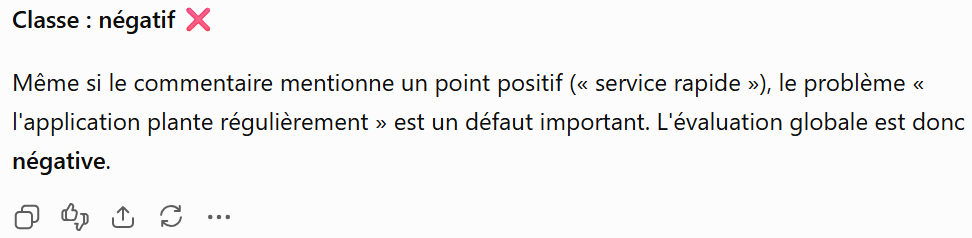

### 2. One-shot
*Un seul exemple de commentaire déjà classé.*

```text
Classe le commentaire en positif, négatif ou neutre.

Exemple :
- « Livraison reçue le lendemain, parfait. » ====> positif

Commentaire à classer : « Le service est rapide mais l'application plante régulièrement. »

Classe :
```

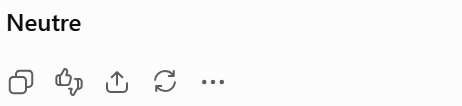

### 3. Few-shot
*Plusieurs exemples, dont un commentaire mixte qui montre comment trancher.*

```text
Classe le commentaire en positif, négatif ou neutre.

Exemples :
- « Produits conformes, bon rapport qualité-prix. » ===> positif
- « Impossible de joindre le service client, aucune réponse. » ===> négatif
- « Commande reçue ce matin. » ===> neutre
- « Prix intéressants mais le colis est arrivé cassé. » ===> négatif

Commentaire à classer : « Le service est rapide mais l'application plante régulièrement. »

Classe :
```

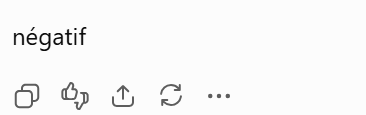

### 4. Prompt structuré

```text
# RÔLE
Tu es un classificateur d'avis clients pour une enseigne de e-commerce.

# TÂCHE
Classe le commentaire dans une seule des classes : positif, négatif, neutre.

# DÉFINITIONS
- positif : le client est satisfait ; ses éventuelles remarques ne gênent pas l'usage du service.
- négatif : le client signale au moins un problème qui gêne l'usage du service, même s'il cite aussi un point positif.
- neutre : le commentaire est factuel, sans opinion.

# FORMAT DE SORTIE
- Classe : positif, négatif ou neutre
- Justification : une phrase citant les mots du commentaire qui motivent le choix

# COMMENTAIRE
« Le service est rapide mais l'application plante régulièrement. »
```

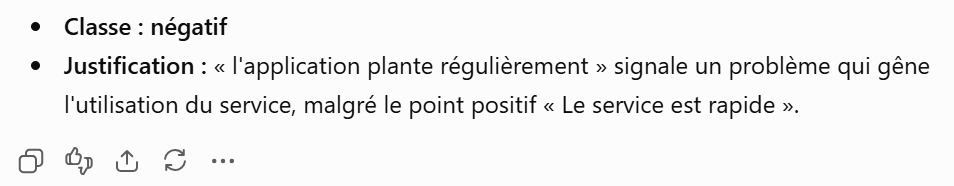

### Évaluation

Le commentaire est **mixte** : il contient un point positif et un problème récurrent. Aucune des trois classes ne s'impose d'elle-même, ce qui permet de voir l'effet de chaque technique.

| Critère | Zero-shot | One-shot | Few-shot | Structuré |
|---|---|---|---|---|
| Classe obtenue | négative | Neutre | négatif | négatif |
| Justification fournie | Présent | Absent | Absent | Présent |
| Format de réponse respecté | Oui | Oui | Oui | Oui |


**Attendu** : sans règle explicite, le modèle risque d'hésiter entre neutre et négatif. Le few-shot (par l'exemple mixte) et le prompt structuré (par les définitions) fixent la règle : un problème qui gêne l'usage l'emporte, donc **négatif**. Seul le prompt structuré impose en plus une justification vérifiable.

# Partie 3 - Prompt Engineering et raisonnement

### 1. Décomposition d'un prompt

*Prompt initial :*

```text
Analyse ces avis clients et donne-moi les problèmes les plus importants ainsi que les recommandations.
```

Ce prompt enchaîne plusieurs tâches en une seule phrase et laisse les critères implicites. On le décompose en étapes :

| Élément du prompt initial | Ce qui reste implicite | Étape explicitée |
|---|---|---|
| « Analyse ces avis » | Quelle analyse ? | 1. Relever le problème signalé dans chaque avis |
| « les problèmes » | Regroupés comment ? | 2. Regrouper par thème et compter les avis |
| « les plus importants » | Selon quels critères ? | 3. Classer selon la fréquence, la gravité et le risque de perdre le client |
| « les recommandations » | Pour quels problèmes ? | 4. Une recommandation par problème prioritaire |
| *(absent)* | Format, justification | 5. Tableau récapitulatif avec les identifiants des avis |

#### Prompt décomposé

```text
Analyse les avis clients ci-dessous en suivant ces étapes, dans l'ordre.

Étape 1 – Relevé : pour chaque avis, indique en une ligne le problème signalé, ou « aucun problème ».
Étape 2 – Regroupement : regroupe les problèmes par thème ; pour chaque thème, donne le nombre d'avis et leurs identifiants.
Étape 3 – Priorisation : classe les thèmes du plus important au moins important selon trois critères : nombre d'avis, gravité (préjudice financier, achat impossible), risque de perdre le client. Justifie chaque rang en une phrase.
Étape 4 – Recommandations : pour les 3 problèmes prioritaires, propose une recommandation concrète qui traite directement le problème.
Étape 5 – Synthèse : termine par un tableau Rang | Problème | Avis concernés | Recommandation.

Contrainte : utilise uniquement les avis fournis et n'invente aucune cause.

<avis>
A01 : Application très pratique, je commande en 2 minutes. Livraison reçue le lendemain, parfait.
A02 : Ma commande devait arriver mardi, je l'ai reçue le samedi suivant. Personne ne m'a prévenu du retard.
A03 : L'application plante à chaque fois que je veux payer par carte. J'ai dû passer par le site.
A04 : Le conseiller a été très aimable et a résolu mon problème de remboursement en un appel.
A05 : Le service est rapide mais l'application plante régulièrement.
A06 : J'ai été débité deux fois pour la même commande (45 000 FCFA). J'attends un remboursement depuis 10 jours, sans réponse.
A07 : Produits conformes à la description, bon rapport qualité-prix.
A08 : Troisième retard de livraison ce mois-ci. Si ça continue, je vais chez un concurrent.
A09 : Colis arrivé avec l'emballage déchiré, mais le produit était intact.
A10 : Impossible de joindre le service client : 40 minutes d'attente au téléphone et aucune réponse au chat.
A11 : Depuis la dernière mise à jour, l'appli se ferme toute seule sur mon téléphone Android.
A12 : Les frais de livraison ont augmenté sans que ce soit annoncé clairement.
</avis>
```

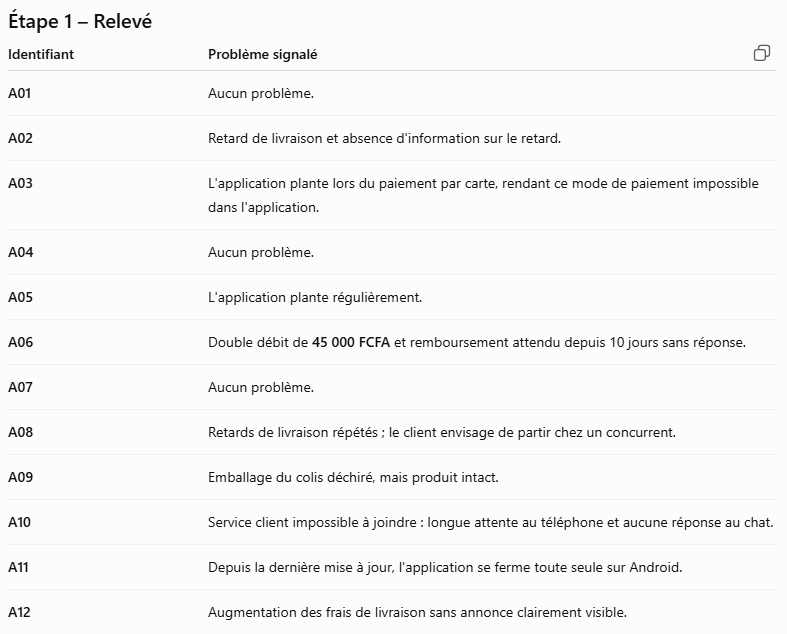
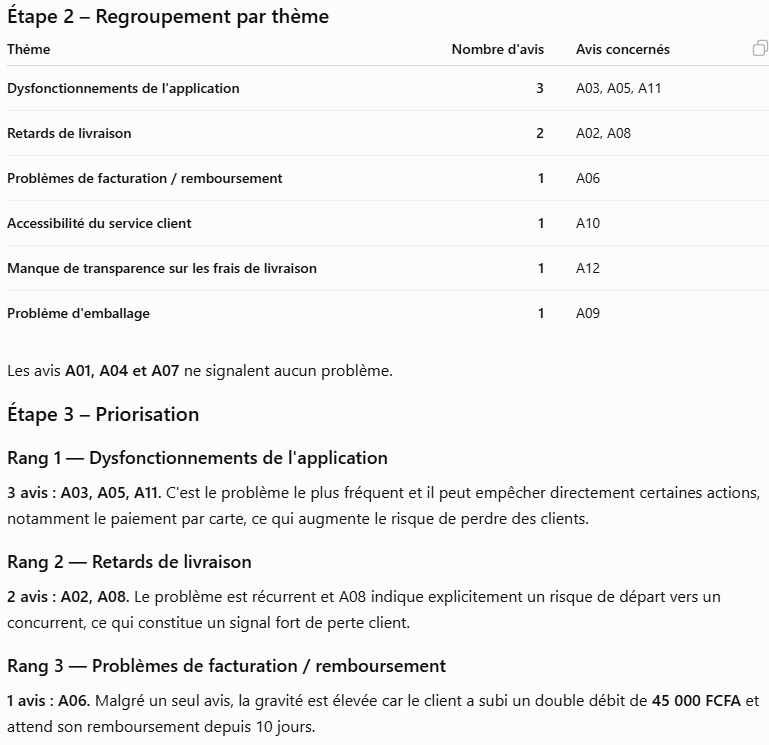
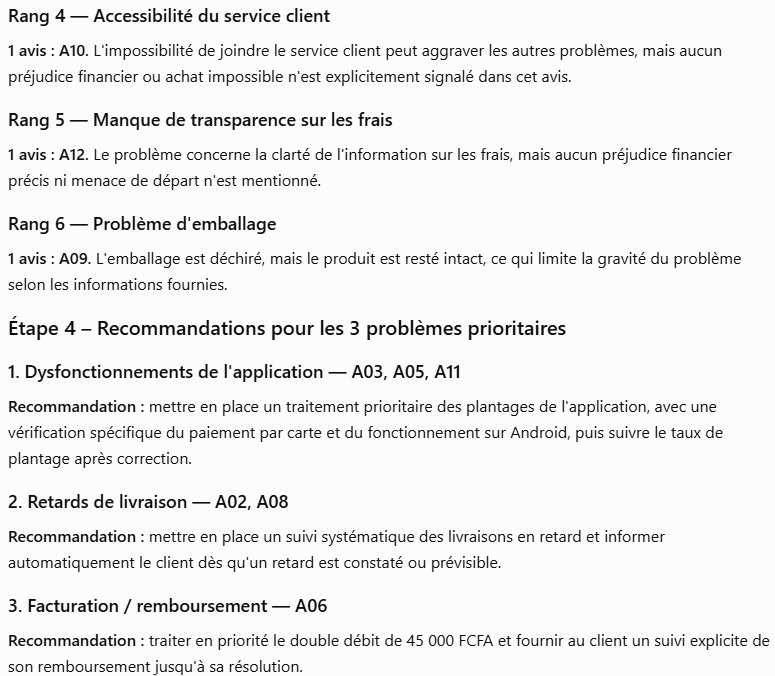
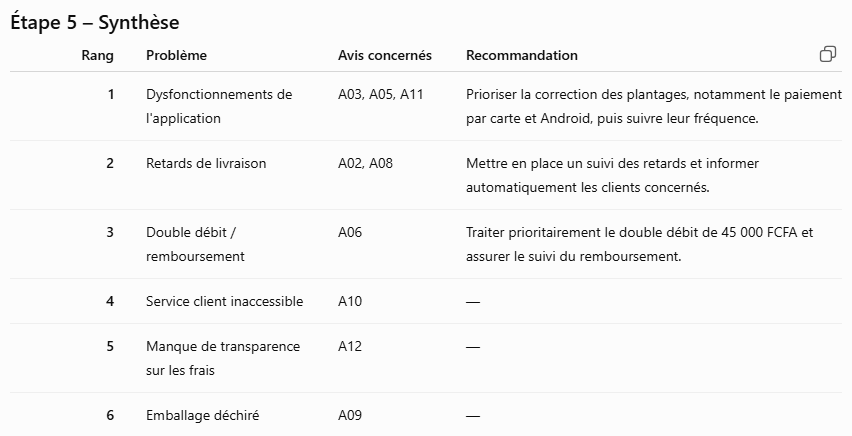

### 2. Analyse sous contraintes puis auto-vérification


#### Prompt 1 – Analyse

```text
# TÂCHE
À partir du rapport ci-dessous, rédige une note d'analyse pour la direction.

# CONTENU ATTENDU
1. Trois points forts
2. Trois points faibles
3. La cause principale de la hausse des retards de livraison
4. Le résultat du test du nouveau transporteur
5. Deux recommandations

# CONTRAINTES
- Utilise uniquement les informations du rapport.
- Chaque point doit citer le chiffre ou la phrase du rapport qui le justifie.
- Si une information n'est pas dans le rapport, écris « non précisé dans le rapport ».
- 150 mots maximum.
- Réponds sous forme de liste numérotée.

# RAPPORT
<rapport>
Rapport d'activité ShopNet – 2e trimestre 2026
Au 2e trimestre, ShopNet a réalisé un chiffre d'affaires de 1,2 milliard FCFA, en hausse de 8 % par rapport au 1er trimestre. Le nombre de commandes est passé de 35 000 à 38 000. La part des commandes livrées en retard est passée de 9 % à 14 %. La note moyenne de l'application mobile est tombée de 4,2 à 3,1 sur 5 après la mise à jour du mois de mai. Le délai moyen de réponse du service client est de 36 heures, pour un objectif de 24 heures. Un nouveau transporteur est testé à Thiès depuis juin ; les résultats de ce test seront présentés au prochain comité. Le taux de clients ayant commandé au moins deux fois est resté stable à 42 %.
</rapport>
```

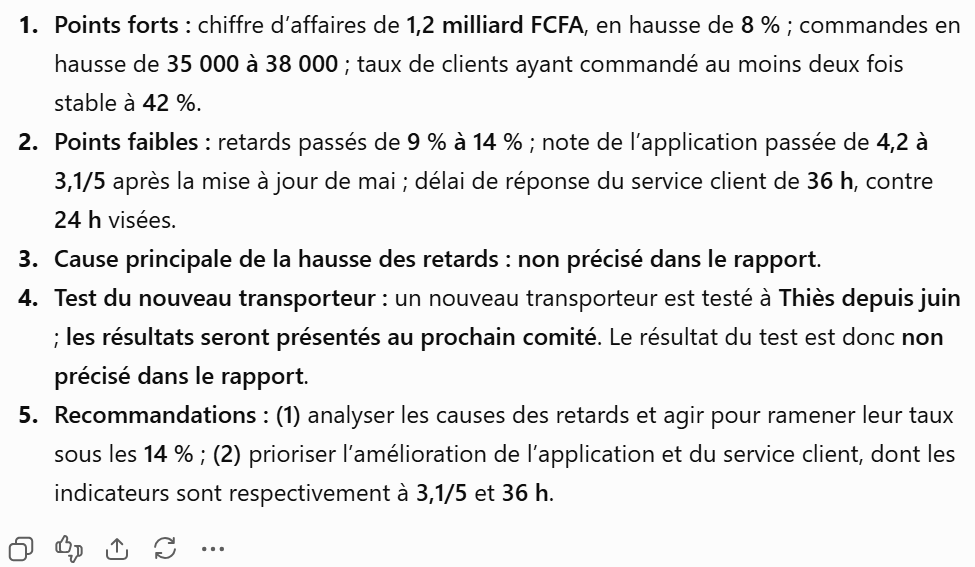

#### Prompt 2 – Vérification

```text
# RÔLE
Tu es relecteur chargé du contrôle qualité.

# TÂCHE
Vérifie ta réponse précédente en la comparant, point par point, au rapport fourni.

# CONTRÔLES À EFFECTUER
1. Informations non justifiées : chaque affirmation s'appuie-t-elle sur un passage du rapport ? Une simple succession de faits a-t-elle été présentée comme une cause ?
2. Contradictions : la réponse contredit-elle le rapport, ou se contredit-elle ?
3. Informations absentes : pour les questions sans réponse dans le rapport, as-tu écrit « non précisé dans le rapport » ? As-tu oublié une information importante du rapport ?
4. Hallucinations : y a-t-il des chiffres, causes, dates ou noms qui ne figurent pas dans le rapport ?
5. Respect des contraintes : nombre de points, justification citée, 150 mots maximum, liste numérotée.

# FORMAT DE SORTIE
1. Tableau : Contrôle | Résultat (OK / Problème) | Détail | Passage du rapport concerné
2. Réponse corrigée, uniquement si au moins un problème a été détecté. Ne modifie rien de ce qui est correct.
```

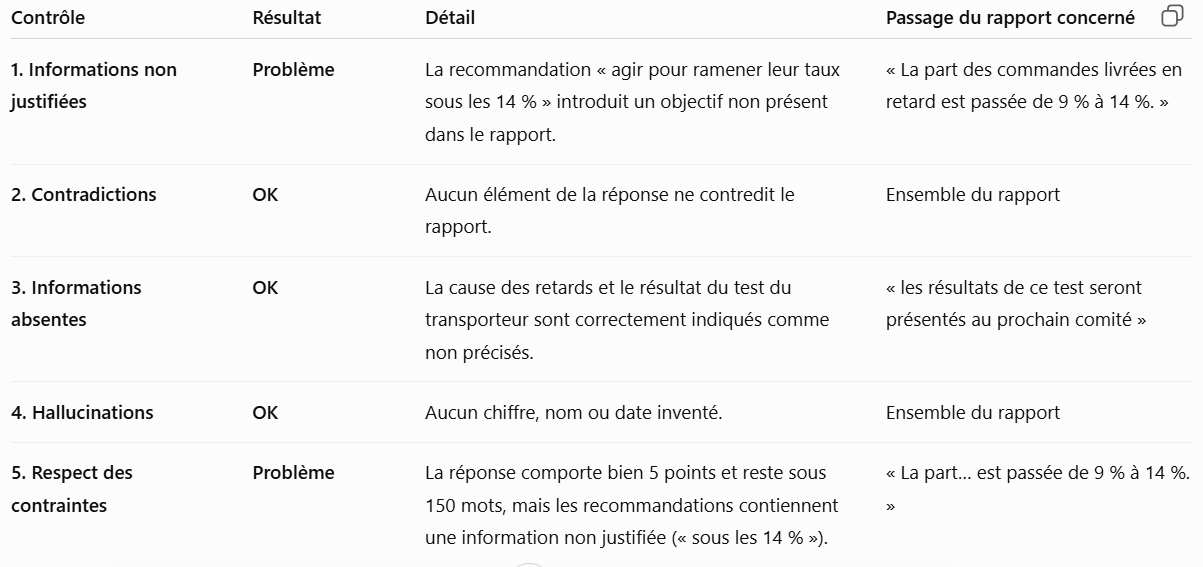
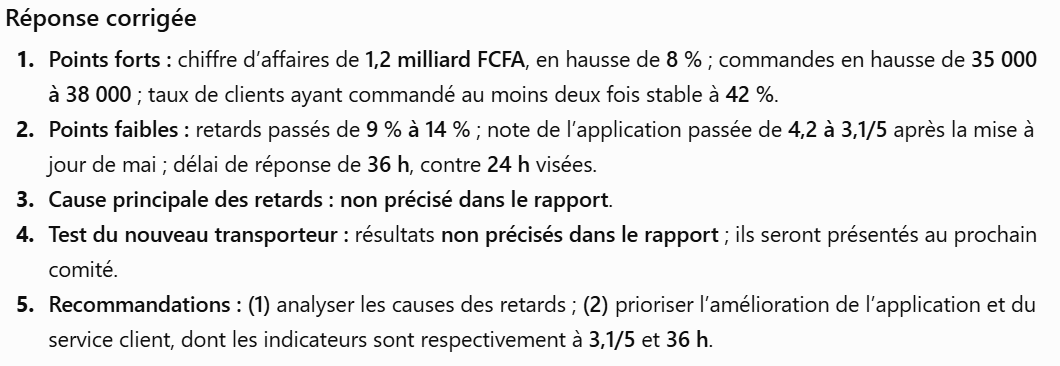

### Évaluation

| Point à vérifier | Attendu | Réponse au prompt 1 | Après vérification |
|---|---|---|---|
| Cause de la hausse des retards | « non précisé dans le rapport » |  « non précisé dans le rapport » |  Inchangé |
| Résultat du test du transporteur | « non précisé » (présenté au prochain comité) |  « non précisé dans le rapport », avec le rappel du comité |  Même contenu, formulé plus court |
| Baisse de la note de l'application | Survenue après la mise à jour de mai, sans cause établie |  « passée de 4,2 à 3,1/5 après la mise à jour de mai » : lien seulement chronologique |  Inchangé |
| Chiffres cités | Tous présents dans le rapport |  Chiffres exacts, mais la recommandation « ramener leur taux sous les 14 % » ajoute un objectif absent du rapport |  Objectif détecté (contrôle 1) et supprimé |
| Contraintes (format, ≤ 150 mots) | Respectées |  5 points numérotés et justifiés, 147 mots (limite presque atteinte) |  117 mots |

**Bilan** : ChatGPT n'est pas tombé dans les pièges des points 3 et 4 : il a répondu « non précisé » au lieu d'inventer. Sa seule erreur est un objectif chiffré ajouté dans une recommandation. Le prompt de vérification l'a repéré et corrigé sans toucher au reste. Il l'a toutefois compté deux fois (contrôles 1 et 5), alors que le format et la longueur étaient respectés.

# Partie 4 - Sorties structurées

Le LLM retourne : « *Le commentaire semble plutôt négatif. Le client est mécontent du délai de livraison...* »

Ce texte libre est difficile à exploiter par une application : il faut le relire pour en extraire le sentiment, la catégorie ou l'urgence. On demande donc une sortie **JSON**.

### 1. Prompt JSON avec types et valeurs autorisées

```text
# TÂCHE
Analyse le commentaire client ci-dessous et retourne le résultat au format JSON.

# CHAMPS ATTENDUS
- sentiment (chaîne) : "positif", "negatif" ou "neutre"
- categorie (chaîne) : "livraison", "application", "paiement", "service_client", "produit", "prix" ou "autre"
- urgence (chaîne) : "faible", "moyenne" ou "élevée"
- probleme (chaîne) : le problème principal en 10 mots maximum, ou "aucun"
- confiance (nombre décimal) : ta confiance dans l'analyse, entre 0 et 1

# FORMAT DE SORTIE
Réponds uniquement avec l'objet JSON, sans texte avant ni après.
Exemple de résultat :
{
  "sentiment": "negatif",
  "categorie": "livraison",
  "urgence": "moyenne",
  "probleme": "Retard de livraison",
  "confiance": 0.91
}

# COMMENTAIRE
« J'ai été débité deux fois pour la même commande (45 000 FCFA). J'attends un remboursement depuis 10 jours, sans réponse. »
```

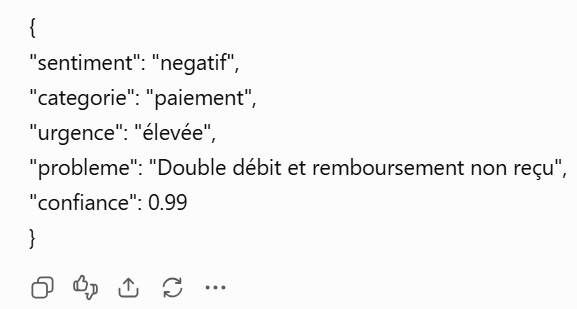

### 2. Prompt JSON avec règles de validation

*Le commentaire est choisi pour tenter le modèle d'enfreindre les règles : sentiment mixte (tentation de répondre « mitigé »), deux problèmes (tentation de deux catégories) et une demande de remboursement (tentation d'ajouter un champ).*

```text
# TÂCHE
Analyse le commentaire client ci-dessous et retourne le résultat au format JSON.

# SCHÉMA
{
  "sentiment": "positif" | "negatif" | "neutre",
  "categorie": "livraison" | "application" | "paiement" | "service_client" | "produit" | "prix" | "autre",
  "urgence": "faible" | "moyenne" | "élevée",
  "probleme": chaîne de 10 mots maximum, ou "aucun",
  "confiance": nombre entre 0 et 1
}

# RÈGLES DE SORTIE (obligatoires)
1. Format JSON valide : guillemets doubles, aucune virgule finale, aucun commentaire, aucune balise de code.
2. Aucune propriété supplémentaire : exactement les 5 champs du schéma.
3. sentiment vaut exactement "positif", "negatif" ou "neutre" ; un avis mixte est classé selon le point dominant.
4. confiance est un nombre (et non une chaîne) compris entre 0 et 1.
5. urgence vaut exactement "faible", "moyenne" ou "élevée".
6. Si le commentaire signale plusieurs problèmes, retiens le plus grave dans categorie et probleme.

Avant de répondre, vérifie que ta sortie respecte chaque règle.
Réponds uniquement avec l'objet JSON.

# COMMENTAIRE
« Livreur très sympa, mais le colis est arrivé avec 5 jours de retard et on m'a facturé deux fois les frais de port. Je veux être remboursé ! »
```

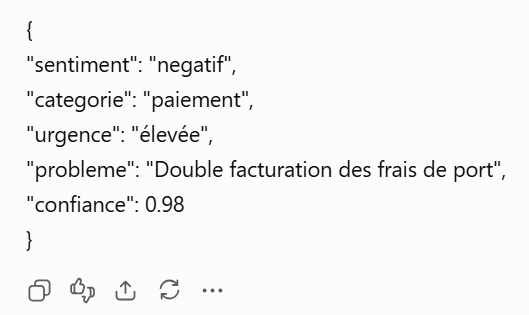

#### Validation automatique de la réponse

Le prompt demande de respecter les règles, mais ne le garantit pas : une application doit toujours **vérifier** la sortie du LLM avant de l'utiliser. Le code ci-dessous traduit les règles de sortie en schéma JSON et contrôle la réponse de ChatGPT.

In [ ]:
import json
from jsonschema import Draft202012Validator

# Règles de sortie traduites en schéma JSON
SCHEMA = {
    "type": "object",
    "properties": {
        "sentiment": {"enum": ["positif", "negatif", "neutre"]},
        "categorie": {"enum": ["livraison", "application", "paiement", "service_client", "produit", "prix", "autre"]},
        "urgence": {"enum": ["faible", "moyenne", "élevée"]},
        "probleme": {"type": "string"},
        "confiance": {"type": "number", "minimum": 0, "maximum": 1},
    },
    "required": ["sentiment", "categorie", "urgence", "probleme", "confiance"],
    "additionalProperties": False,  # aucune propriété supplémentaire
}


def valider(reponse: str) -> None:
    """Affiche si la réponse du LLM respecte les règles de sortie."""
    try:
        data = json.loads(reponse)
    except json.JSONDecodeError as e:
        print(f" JSON invalide : {e}")
        return

    erreurs = list(Draft202012Validator(SCHEMA).iter_errors(data))
    if not erreurs:
        print(" Sortie valide : toutes les règles sont respectées")
    for err in erreurs:
        if err.validator == "additionalProperties":
            extras = sorted(set(err.instance) - set(SCHEMA["properties"]))
            print(f" Propriété(s) supplémentaire(s) : {extras}")
        elif err.validator == "required":
            print(f" Champ manquant : {err.message.split()[0]}")
        elif err.validator == "enum":
            print(f" {err.path[0]} = {err.instance!r} : valeur non autorisée {err.validator_value}")
        elif err.validator in ("minimum", "maximum"):
            print(f" {err.path[0]} = {err.instance} : doit être compris entre 0 et 1")
        else:
            print(f" {'.'.join(map(str, err.path))} : type incorrect (attendu : {err.validator_value})")

In [ ]:
# Réponse de ChatGPT au prompt 2
reponse_chatgpt = """
{
"sentiment": "negatif",
"categorie": "paiement",
"urgence": "élevée",
"probleme": "Double facturation des frais de port",
"confiance": 0.98
}

"""
print("Réponse de ChatGPT :")
valider(reponse_chatgpt)

# Contre-exemple : une réponse qui enfreint plusieurs règles
print("\nContre-exemple :")
valider('{"sentiment": "mitigé", "categorie": "livraison", "urgence": "haute", '
        '"probleme": "Retard", "confiance": 1.2, "action": "rembourser"}')

Réponse de ChatGPT :
✅ Sortie valide : toutes les règles sont respectées

Contre-exemple :
❌ sentiment = 'mitigé' : valeur non autorisée ['positif', 'negatif', 'neutre']
❌ urgence = 'haute' : valeur non autorisée ['faible', 'moyenne', 'élevée']
❌ confiance = 1.2 : doit être compris entre 0 et 1
❌ Propriété(s) supplémentaire(s) : ['action']


# Partie 5 - Prompts pour les applications métier

### 1. Résumé d'un document

*Pièges : le document précise que l'effet sur les retards n'a pas été mesuré et que le coût n'est pas encore chiffré. Le résumé ne doit rien affirmer sur ces deux points.*

```text
# RÔLE
Tu es analyste chargé de synthétiser des documents pour la direction.

# TÂCHE
Résume le document fourni entre les balises <document> et </document>.

# CONTRAINTES
- 250 mots maximum.
- Conserve les informations factuelles : chiffres, dates, périmètre.
- Identifie les objectifs, les résultats et les recommandations.
- N'invente aucune information : ne mentionne rien qui ne figure pas dans le document.

# FORMAT DE SORTIE
Contexte : 2 phrases maximum
Objectifs : liste
Résultats : liste, en indiquant pour chaque objectif s'il est atteint
Recommandations : liste

# DOCUMENT
<document>
Rapport de fin de projet – Pilote « Suivi de livraison en temps réel »
Direction des opérations – ShopNet – Août 2026

Contexte
Au premier semestre 2026, 14 % des commandes ShopNet ont été livrées en retard et le service client a reçu en moyenne 1 200 appels par mois demandant « où en est ma commande ? ». Ces appels représentent 38 % du volume total du service client. Pour réduire ce volume et améliorer la satisfaction, la direction des opérations a lancé un pilote de suivi de livraison en temps réel à Dakar, du 1er juin au 31 juillet 2026.

Objectifs
Le pilote visait trois objectifs : réduire de 30 % les appels liés au suivi des commandes, porter la note de satisfaction livraison de 3,4 à 4 sur 5, et vérifier que les livreurs pouvaient utiliser l'application de suivi sans ralentir leurs tournées.

Déroulement
Quarante livreurs, sur les 120 que compte ShopNet à Dakar, ont été équipés d'un smartphone avec l'application de suivi. Les clients recevaient un SMS contenant un lien pour suivre leur colis sur une carte, ainsi qu'une notification trente minutes avant l'arrivée. Au total, 9 800 commandes ont été livrées dans le cadre du pilote. Une formation d'une demi-journée a été organisée pour les livreurs participants.

Résultats
Les appels liés au suivi des commandes ont baissé de 41 % dans la zone du pilote, dépassant l'objectif. La note de satisfaction livraison est passée de 3,4 à 4,1 sur 5. Le taux de livraisons réussies au premier passage a progressé de 81 % à 89 %, car les clients étaient plus souvent présents à l'arrivée du livreur. En revanche, la durée moyenne des tournées a augmenté de 6 % pendant les deux premières semaines, avant de revenir à son niveau habituel. Enfin, 7 % des SMS n'ont pas été reçus, principalement en raison de numéros de téléphone mal saisis lors de la commande.

Difficultés rencontrées
Les livreurs ont signalé une consommation élevée de la batterie des smartphones. Dans certains quartiers, une couverture réseau insuffisante a provoqué des interruptions du suivi sur la carte.

Recommandations
L'équipe projet recommande d'étendre le suivi en temps réel à l'ensemble des livreurs de Dakar d'ici décembre 2026, de fournir une batterie externe à chaque livreur et d'ajouter un contrôle du format du numéro de téléphone lors de la commande. Elle recommande également de mesurer l'effet du dispositif sur le taux de retard, qui n'a pas été suivi pendant le pilote. Le coût d'un déploiement à tout Dakar sera chiffré par la direction financière en septembre 2026.
</document>
```

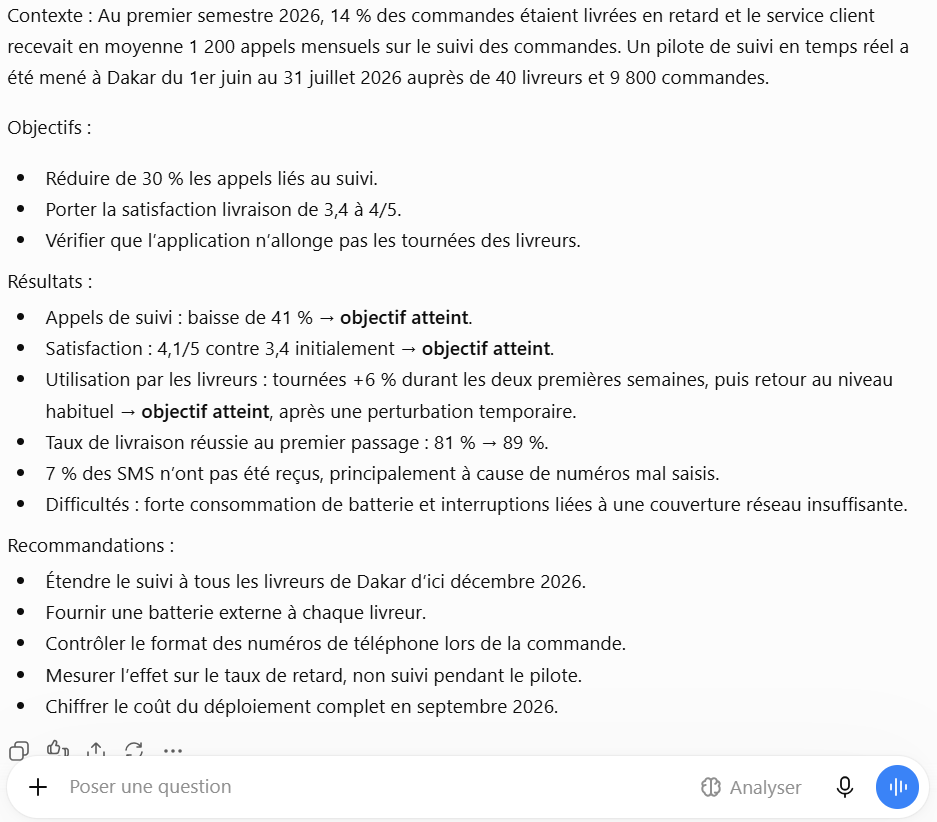

### 2. Traduction français → anglais

```text
# RÔLE
Tu es traducteur technique professionnel, du français vers l'anglais.

# TÂCHE
Traduis en anglais le document fourni entre les balises <document> et </document>.

# CONTRAINTES
1. Conserve le sens exact de chaque phrase.
2. Conserve la structure : titres, listes, numérotation et ordre des paragraphes.
3. Conserve les termes techniques (API, webhook, back-end, HTTPS, timeout) et ne traduis pas les noms propres (ShopNet, Orange Money, Wave).
4. Ne résume pas : chaque phrase du texte source doit avoir sa traduction.
5. N'ajoute aucune information, explication ou note du traducteur.

# FORMAT DE SORTIE
Uniquement la traduction, sans commentaire avant ni après.

# DOCUMENT
<document>
Note technique : intégration du paiement mobile dans l'application ShopNet

Objet
Cette note décrit les étapes d'intégration du paiement mobile (Orange Money, Wave) dans l'application ShopNet.

Prérequis
- Disposer d'une clé API de production fournie par l'opérateur.
- Configurer l'URL du webhook qui reçoit les notifications de paiement.
- Activer le protocole HTTPS sur le serveur back-end.

Étapes
1. Le client valide son panier et choisit « Paiement mobile ».
2. Le back-end envoie une requête de paiement à l'API de l'opérateur avec le montant et l'identifiant de la commande.
3. Le client confirme le paiement sur son téléphone avec son code secret.
4. L'opérateur envoie le résultat au webhook ; la commande passe au statut « payée » uniquement si la signature de la notification est valide.

Points de vigilance
En cas de timeout (aucune réponse après 30 secondes), la commande reste « en attente » et ne doit jamais être validée automatiquement. Les tentatives de paiement sont limitées à 3 par commande.
</document>
```

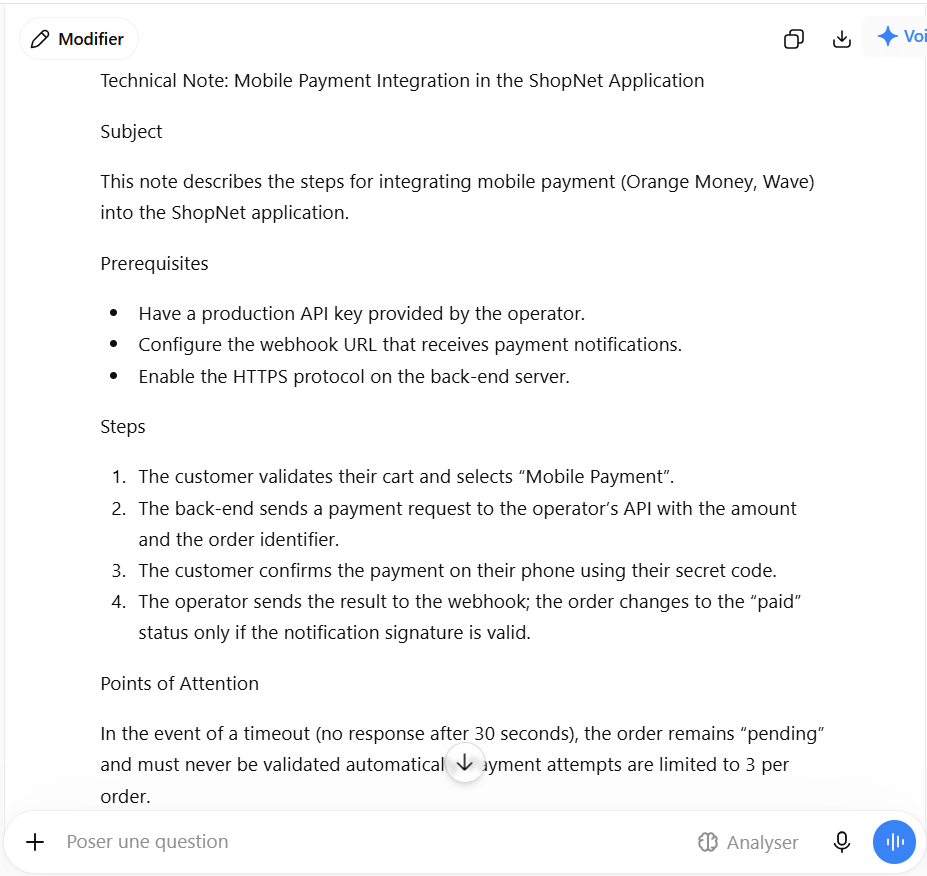


### 3. Classification d'un ticket informatique

*Piège : le ticket ressemble à un problème d'accès (mot de passe refusé), mais l'email de la veille indique un hameçonnage probable. La catégorie attendue est « sécurité ».*

```text
# RÔLE
Tu es technicien du support informatique chargé de trier les tickets.

# TÂCHE
Classe le ticket ci-dessous dans une seule catégorie.

# CATÉGORIES
- reseau : connexion internet, Wi-Fi, VPN, lenteur du réseau
- logiciel : bug, installation ou mise à jour d'une application
- materiel : poste, imprimante, écran ou périphérique défectueux
- securite : virus, hameçonnage, compte compromis, fuite de données
- acces : mot de passe oublié, compte bloqué, droits insuffisants
- autre : demande qui ne relève d'aucune catégorie ci-dessus

# RÈGLE
Si plusieurs catégories sont possibles, choisis celle qui présente le risque le plus élevé pour l'entreprise : securite l'emporte sur toutes les autres.

# FORMAT DE SORTIE
Réponds uniquement avec un JSON valide, sans texte avant ni après :
{
  "categorie": "reseau" | "logiciel" | "materiel" | "securite" | "acces" | "autre",
  "justification": "1 à 2 phrases citant les éléments du ticket qui motivent le choix"
}

# TICKET
Ticket n° 4521 – Service comptabilité
Objet : Impossible d'accéder à ma messagerie
Depuis ce matin, je ne peux plus me connecter à ma messagerie Outlook : le message « mot de passe incorrect » s'affiche alors que je ne l'ai pas changé. Hier, j'ai reçu un email du « support informatique » me demandant de confirmer mes identifiants via un lien, ce que j'ai fait.
```

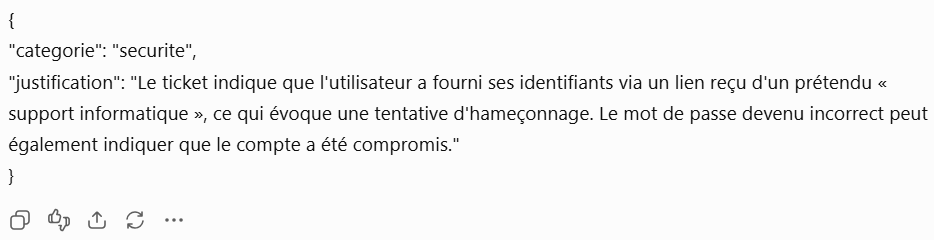

### 4. Extraction des informations d'une facture

*Pièges : la date est illisible (valeur attendue : null) et la facture mentionne deux entreprises, l'émetteur et le client.*

```text
# TÂCHE
Extrais les informations de la facture ci-dessous.

# CHAMPS À EXTRAIRE
- numero_facture (chaîne)
- date (chaîne au format AAAA-MM-JJ)
- client (chaîne) : l'entreprise facturée, et non l'émetteur
- montant_ht (nombre, en FCFA)
- tva (nombre) : montant de la TVA en FCFA, et non le taux
- montant_ttc (nombre, en FCFA)

# RÈGLES
- Retourne uniquement un JSON valide, sans texte avant ni après.
- Si une information est absente ou illisible, mets null.
- Ne calcule et ne devine aucune valeur manquante.
- Écris les montants sans espace ni unité (ex. 115000).

# FACTURE
FACTURE N° FA-2026-0147
Date : ██/██/2026 (illisible)
Émetteur : ShopNet SARL – Dakar
Client : Boutique Keur Awa, Rue 10, Médina, Dakar

Désignation            Qté    PU (FCFA)    Total (FCFA)
Carton d'emballage L   200    350          70 000
Ruban adhésif          50     900          45 000

Total HT : 115 000 FCFA
TVA (18 %) : 20 700 FCFA
Total TTC : 135 700 FCFA
```

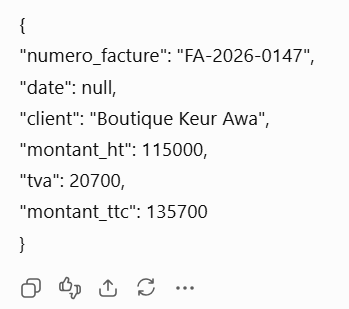

### 5. Email à un client dont la livraison est en retard

*Pièges : la cause du retard est inconnue et seules deux solutions sont autorisées. L'email ne doit inventer ni cause ni geste commercial.*

```text
# RÔLE
Tu es conseiller du service client de ShopNet.

# TÂCHE
Rédige un email à une cliente dont la livraison a pris du retard.

# INFORMATIONS DISPONIBLES
- Cliente : Mme Sarr
- Commande : n° CMD-58213, passée le 2 septembre 2026
- Livraison prévue : 5 septembre 2026
- Situation : la commande est en cours d'acheminement ; nouvelle date de livraison estimée : 12 septembre 2026
- Cause du retard : non connue à ce jour
- Solutions possibles : remboursement des frais de livraison (2 500 FCFA) ou annulation de la commande avec remboursement intégral

# OBJECTIFS
1. Reconnaître le retard.
2. Présenter des excuses.
3. Expliquer la situation sans inventer de cause.
4. Proposer une solution, uniquement parmi celles listées.

# TON
Professionnel, courtois et rassurant.

# CONTRAINTES
- 150 mots maximum.
- N'invente aucune cause, date, promesse ou compensation.
- Signature : « Le service client ShopNet ».

# FORMAT DE SORTIE
Objet : ...
Corps de l'email
```

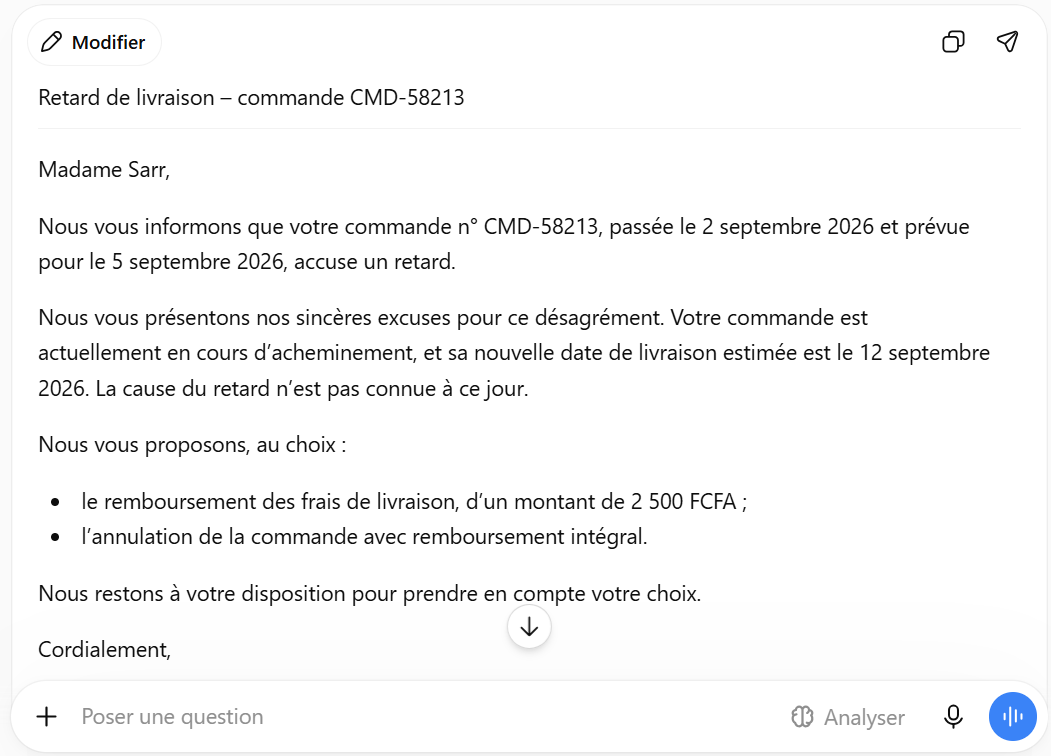

# Partie 6 - Prompt Engineering pour le Machine Learning

Les prompts 1 à 3 contiennent la description du dataset des capteurs (colonnes, valeurs manquantes, doublons, statistiques, extrait). Le fichier complet est dans [data/mesures_capteurs.csv](data/mesures_capteurs.csv) ; on peut aussi le joindre à la conversation ChatGPT.

### 1. Stratégies de traitement des données

*Attendu : repérer les valeurs physiquement impossibles (humidité 145 %, pression 850 hPa, températures -18,5 °C et 58,7 °C en intérieur), les 5 doublons et le déséquilibre de la colonne etat.*

```text
# RÔLE
Tu es data scientist senior, spécialisé dans la préparation de données IoT.

# CONTEXTE
Les données ci-dessous serviront à entraîner un modèle de prédiction de la consommation énergétique des bâtiments.

# TÂCHE
Propose une stratégie de traitement pour quatre problèmes : les valeurs manquantes, les doublons, les valeurs aberrantes et les variables catégorielles.

# INSTRUCTIONS
Pour chaque problème, indique :
1. Détection : comment le repérer, avec le code pandas correspondant (1 à 3 lignes).
2. Constat : ce que la description du dataset permet déjà d'observer (colonnes et valeurs concernées).
3. Traitement recommandé, et une alternative.
4. Risques associés au traitement recommandé.

# CONTRAINTES
- Appuie-toi sur les chiffres de la description ; ne suppose aucune information absente.
- Distingue les valeurs physiquement impossibles des valeurs simplement extrêmes.
- Tiens compte de la nature temporelle des données (mesures horaires par capteur).

# FORMAT DE SORTIE
Une section par problème avec les 4 rubriques, puis un tableau récapitulatif :
Problème | Traitement recommandé | Risque principal

# DATASET
<dataset>
Fichier : mesures_capteurs.csv – mesures horaires de capteurs IoT dans 4 bâtiments, du 05/01/2026 au 29/01/2026
605 lignes, 9 colonnes :
- id_mesure (texte) : identifiant de la mesure
- date_heure (date-heure) : horodatage, une mesure par heure et par capteur
- id_capteur (texte) : 12 capteurs, C001 à C012 (3 par bâtiment)
- batiment (texte) : B001, B002, B003, B004
- temperature (réel, °C)
- humidite (réel, %)
- pression (réel, hPa)
- consommation (réel) : consommation énergétique, unité non précisée
- etat (texte) : OK (567), ALERTE (29), ERREUR (5)

Valeurs manquantes : temperature 6, humidite 5, pression 5, consommation 5, etat 4
Doublons : 5 lignes entièrement dupliquées

Statistiques :
               moyenne   écart-type   min      médiane   max
temperature    24,88     4,06         -18,50   24,86     58,70
humidite       64,93     10,77        28,52    65,38     145,00
pression       1012,22   10,60        850,00   1012,86   1038,43
consommation   208,68    72,24        18,12    206,15    875,00

Extrait :
id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK
</dataset>
```

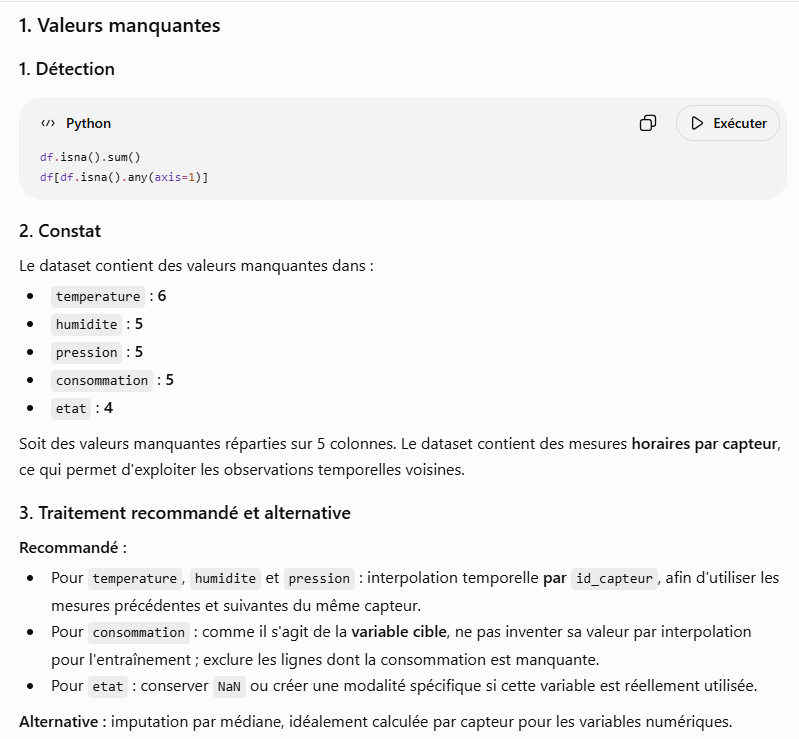
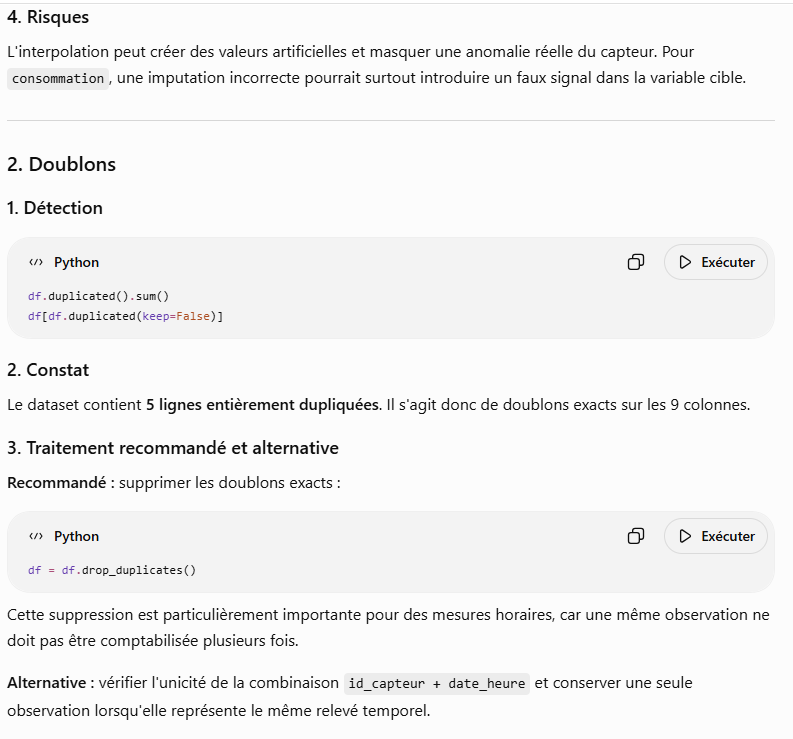
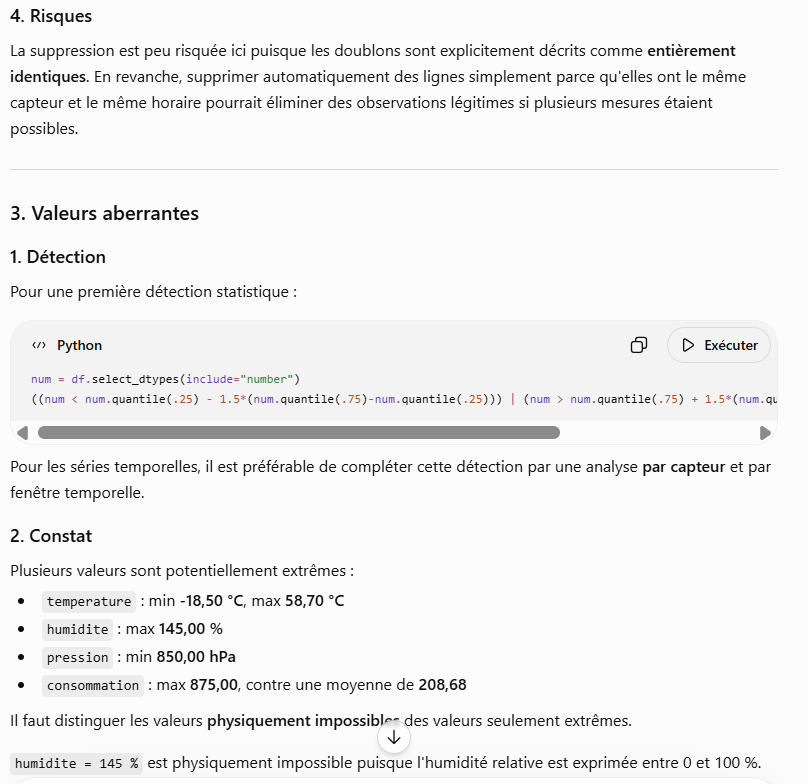
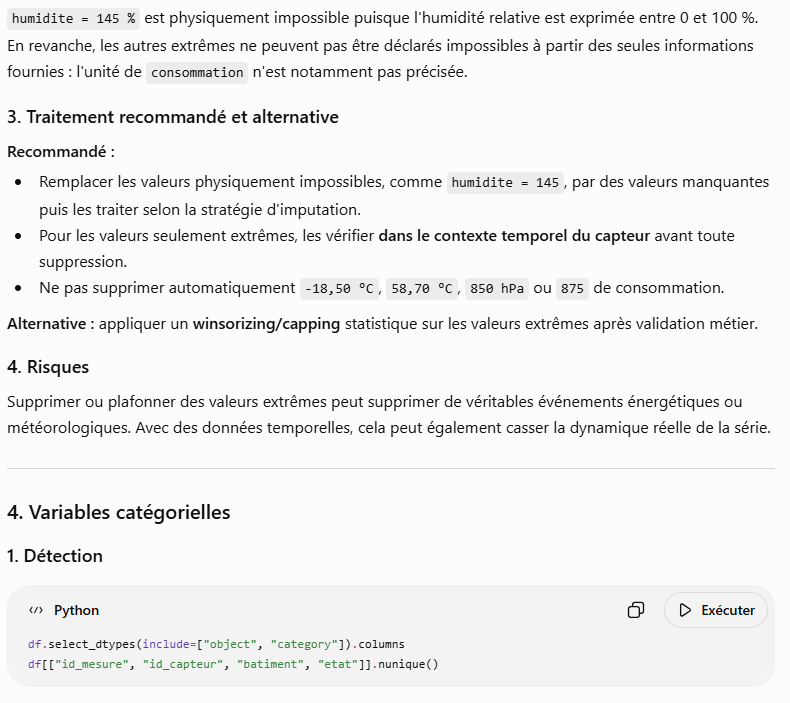
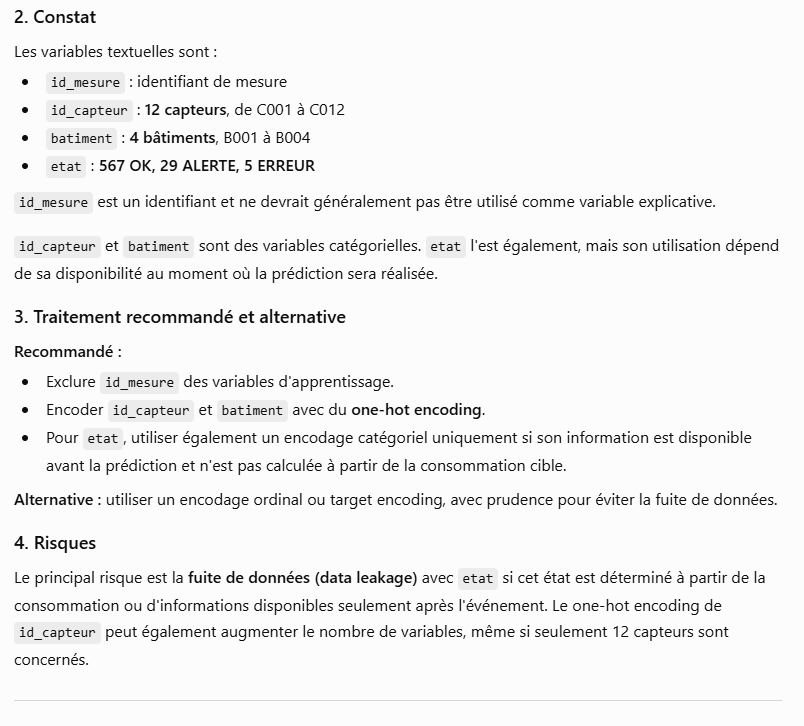
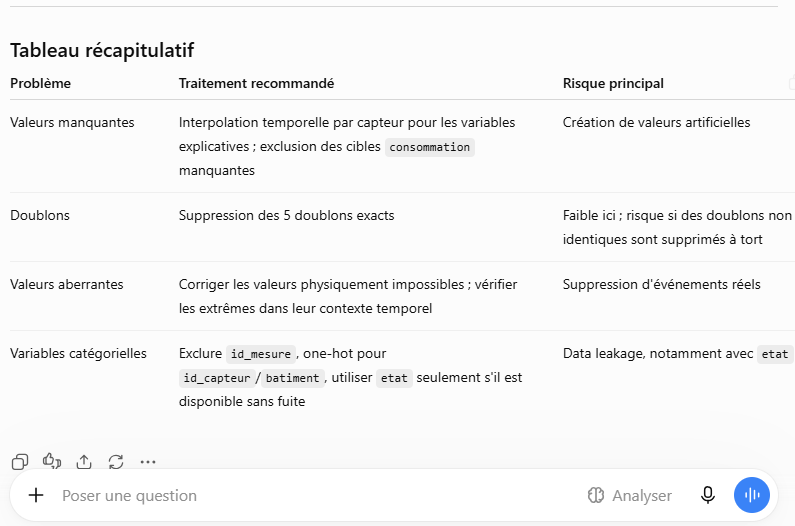

### 2. Visualisations de la consommation énergétique

```text
# RÔLE
Tu es data analyst spécialisé dans l'énergie des bâtiments.

# TÂCHE
Propose les 6 visualisations les plus pertinentes pour comprendre la consommation énergétique des bâtiments à partir du dataset ci-dessous.

# INSTRUCTIONS
Pour chaque visualisation, indique :
- le type de graphique ;
- les variables utilisées ;
- l'objectif ;
- l'interprétation attendue : ce que l'on cherche à voir et comment le lire.
Couvre au moins : l'évolution dans le temps, la comparaison entre bâtiments, la distribution, les relations entre variables, le profil horaire et le lien avec l'état des capteurs.

# CONTRAINTES
- Utilise uniquement les colonnes du dataset.
- Ne présente aucun résultat comme déjà observé : décris ce que le graphique permettra de vérifier.
- Classe les visualisations de la plus utile à la moins utile.

# FORMAT DE SORTIE
Tableau : N° | Type de graphique | Variables | Objectif | Interprétation attendue
Puis, pour chaque visualisation, la fonction Python conseillée (matplotlib ou seaborn), en une ligne.

# DATASET
<dataset>
Fichier : mesures_capteurs.csv – mesures horaires de capteurs IoT dans 4 bâtiments, du 05/01/2026 au 29/01/2026
605 lignes, 9 colonnes :
- id_mesure (texte) : identifiant de la mesure
- date_heure (date-heure) : horodatage, une mesure par heure et par capteur
- id_capteur (texte) : 12 capteurs, C001 à C012 (3 par bâtiment)
- batiment (texte) : B001, B002, B003, B004
- temperature (réel, °C)
- humidite (réel, %)
- pression (réel, hPa)
- consommation (réel) : consommation énergétique, unité non précisée
- etat (texte) : OK (567), ALERTE (29), ERREUR (5)

Valeurs manquantes : temperature 6, humidite 5, pression 5, consommation 5, etat 4
Doublons : 5 lignes entièrement dupliquées

Statistiques :
               moyenne   écart-type   min      médiane   max
temperature    24,88     4,06         -18,50   24,86     58,70
humidite       64,93     10,77        28,52    65,38     145,00
pression       1012,22   10,60        850,00   1012,86   1038,43
consommation   208,68    72,24        18,12    206,15    875,00

Extrait :
id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK
</dataset>
```

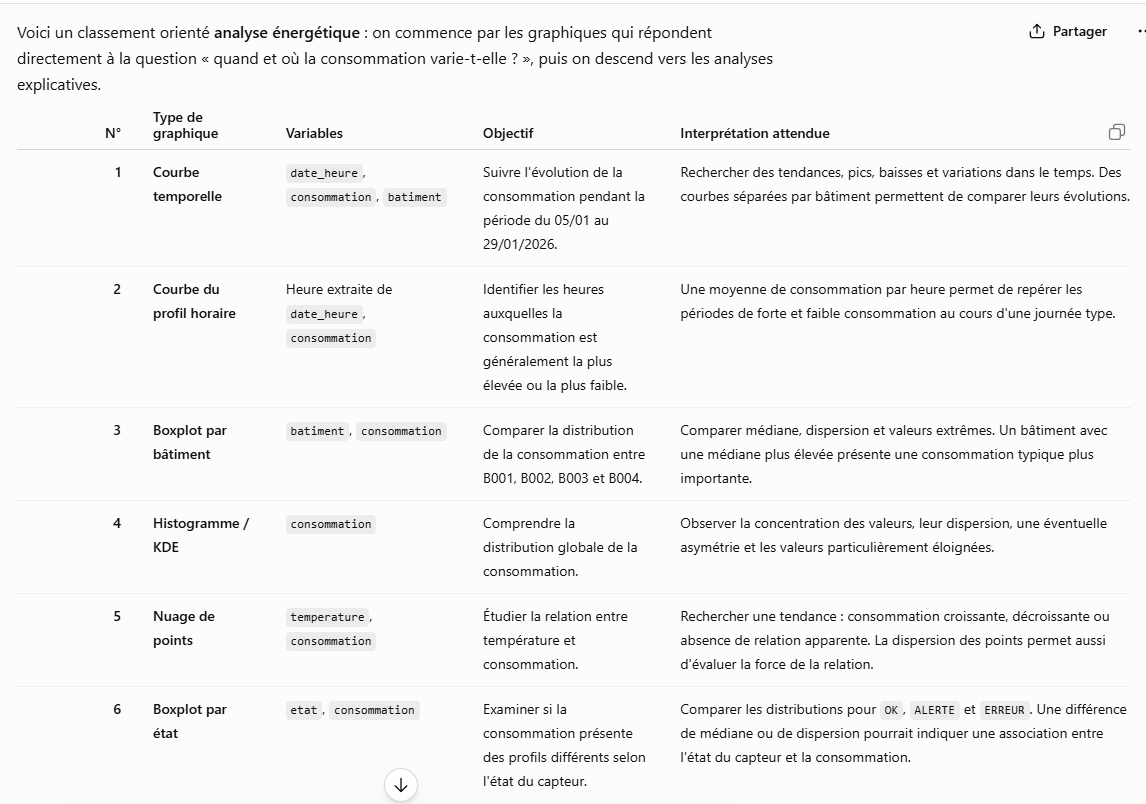
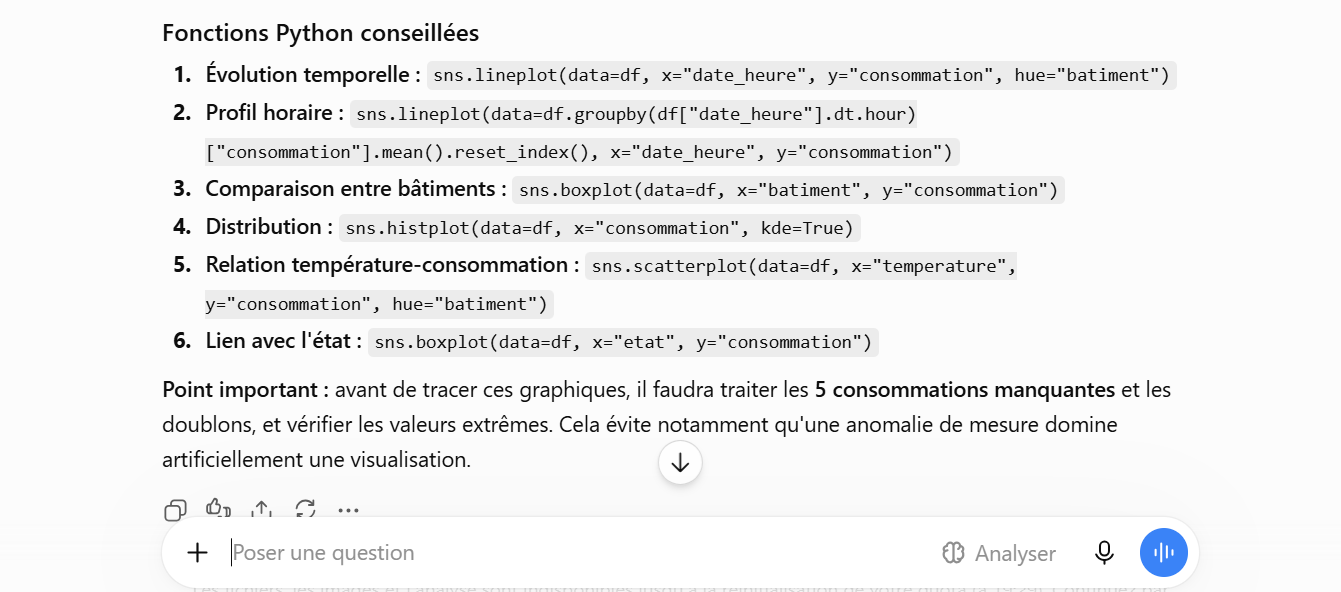

### 3. Modèles de prédiction de la consommation

*Attendu : une référence simple (baseline) et un découpage temporel des données plutôt qu'aléatoire.*

```text
# RÔLE
Tu es data scientist spécialisé en modélisation prédictive.

# TÂCHE
Propose 5 modèles adaptés à la prédiction de la variable consommation à partir du dataset ci-dessous, du plus simple au plus complexe.

# INSTRUCTIONS
Pour chaque modèle, indique :
- le principe (2 phrases maximum) ;
- les avantages ;
- les limites ;
- le type de problème ;
- les métriques pertinentes.
Termine par le modèle que tu recommandes pour ce dataset et la façon de découper les données pour l'évaluer.

# CONTRAINTES
- Tiens compte de la taille du dataset (605 lignes) et de sa nature temporelle.
- Précise les variables d'entrée à utiliser et écarte celles qui ne seraient pas disponibles au moment de la prédiction.
- Commence par une référence simple (baseline) qui permettra de mesurer l'apport des autres modèles.

# FORMAT DE SORTIE
Tableau : Modèle | Principe | Avantages | Limites | Type de problème | Métriques
Puis la recommandation, en 3 phrases maximum.

# DATASET
<dataset>
Fichier : mesures_capteurs.csv – mesures horaires de capteurs IoT dans 4 bâtiments, du 05/01/2026 au 29/01/2026
605 lignes, 9 colonnes :
- id_mesure (texte) : identifiant de la mesure
- date_heure (date-heure) : horodatage, une mesure par heure et par capteur
- id_capteur (texte) : 12 capteurs, C001 à C012 (3 par bâtiment)
- batiment (texte) : B001, B002, B003, B004
- temperature (réel, °C)
- humidite (réel, %)
- pression (réel, hPa)
- consommation (réel) : consommation énergétique, unité non précisée
- etat (texte) : OK (567), ALERTE (29), ERREUR (5)

Valeurs manquantes : temperature 6, humidite 5, pression 5, consommation 5, etat 4
Doublons : 5 lignes entièrement dupliquées

Statistiques :
               moyenne   écart-type   min      médiane   max
temperature    24,88     4,06         -18,50   24,86     58,70
humidite       64,93     10,77        28,52    65,38     145,00
pression       1012,22   10,60        850,00   1012,86   1038,43
consommation   208,68    72,24        18,12    206,15    875,00

Extrait :
id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK
</dataset>
```

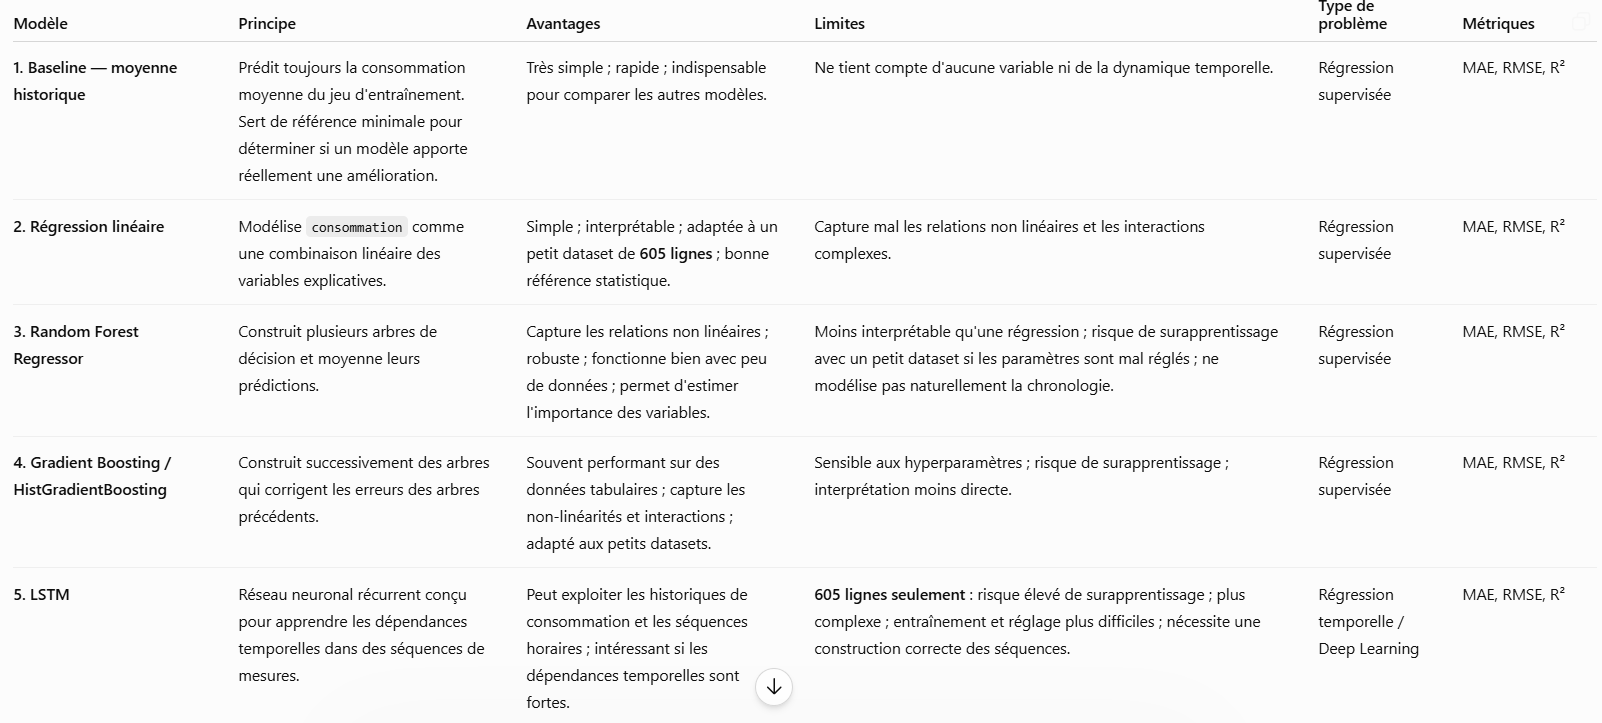
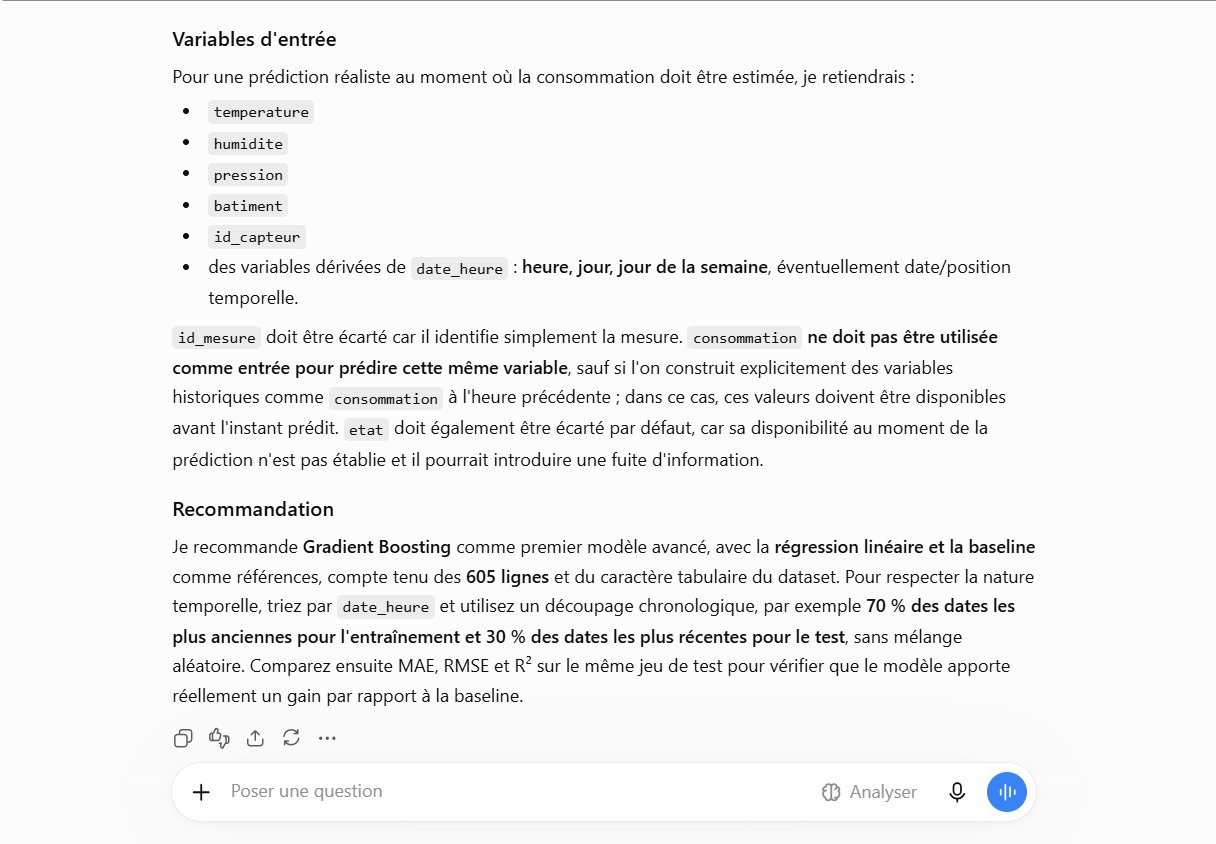

### 4. Explication des métriques de classification

*Valeurs attendues pour l'exemple : Accuracy 0,94 ; Precision 0,75 ; Recall 0,60 ; F1-score ≈ 0,67. Un modèle qui répond toujours « OK » obtiendrait déjà une accuracy de 0,90, avec un recall de 0.*

```text
# RÔLE
Tu es formateur en machine learning pour des analystes débutants.

# TÂCHE
Explique les métriques de classification suivantes : Accuracy, Precision, Recall, F1-score et ROC-AUC.

# INSTRUCTIONS
Pour chaque métrique, donne :
1. La définition, avec sa formule.
2. L'interprétation : ce que signifie une valeur élevée ou faible.
3. Un exemple concret, calculé à partir du cas ci-dessous.
4. Le contexte dans lequel elle est particulièrement utile.

# CAS À UTILISER POUR LES EXEMPLES
Un modèle prédit si un capteur est en ALERTE à partir de ses mesures. Sur 100 mesures de test, 10 sont réellement en ALERTE et 90 sont OK.
Le modèle détecte 6 des 10 alertes et déclenche 2 fausses alertes sur des mesures OK.
Pour la ROC-AUC, explique le principe sans inventer de valeur.

# CONTRAINTES
- Vocabulaire simple ; explique chaque terme anglais.
- Montre le détail de chaque calcul.
- Souligne le piège des classes déséquilibrées.

# FORMAT DE SORTIE
Une section par métrique avec les 4 rubriques, puis un tableau récapitulatif :
Métrique | Question à laquelle elle répond | Quand l'utiliser
```

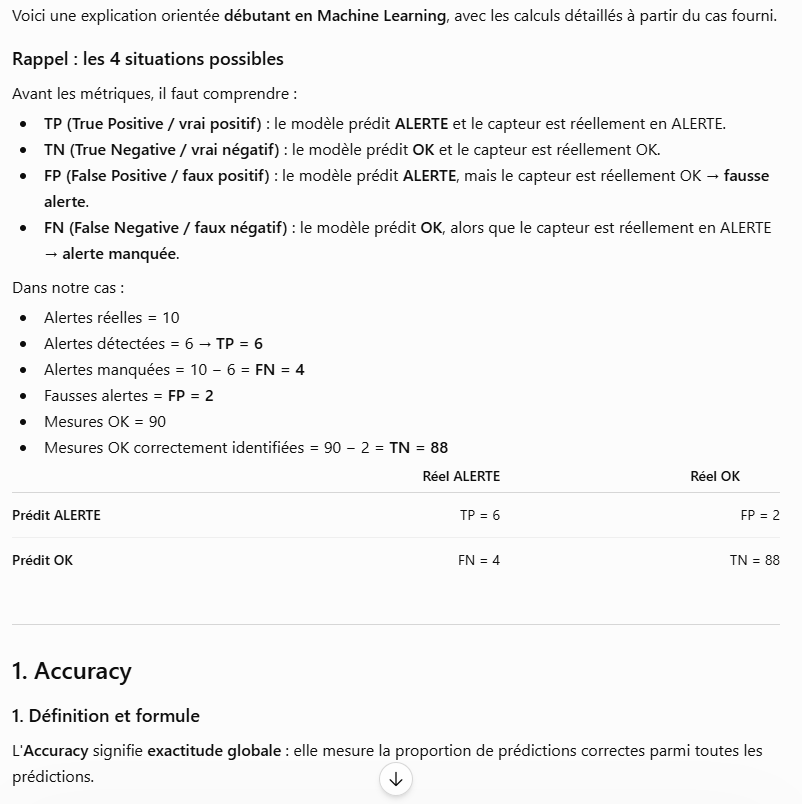
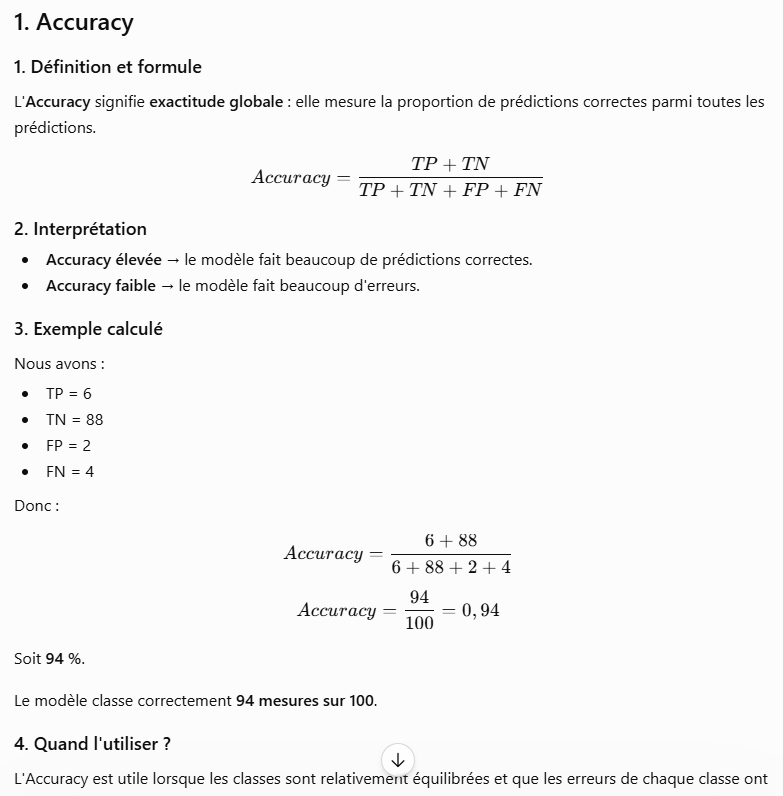
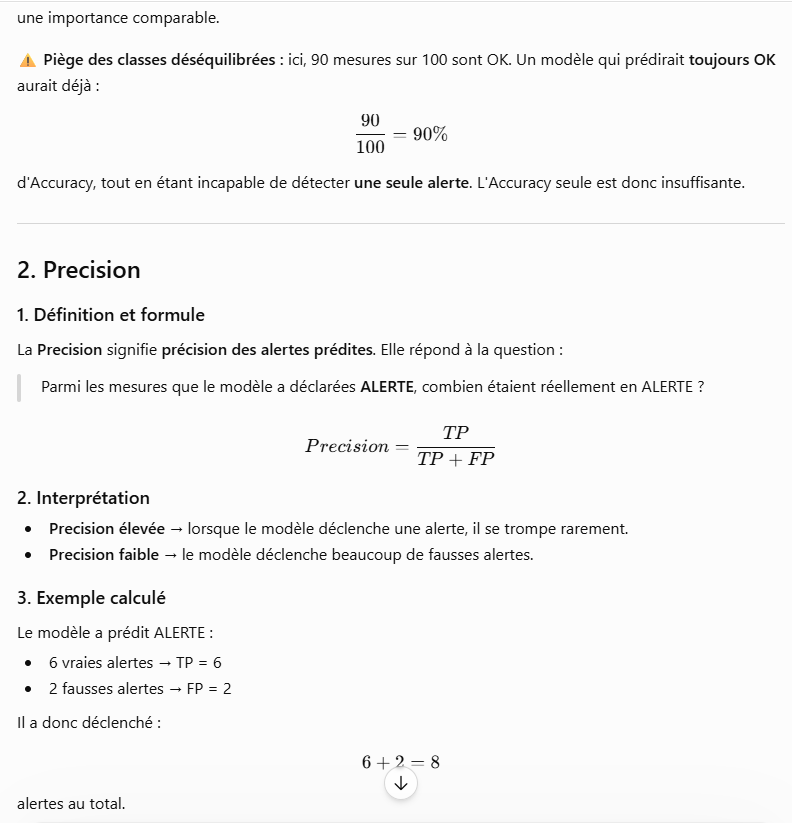
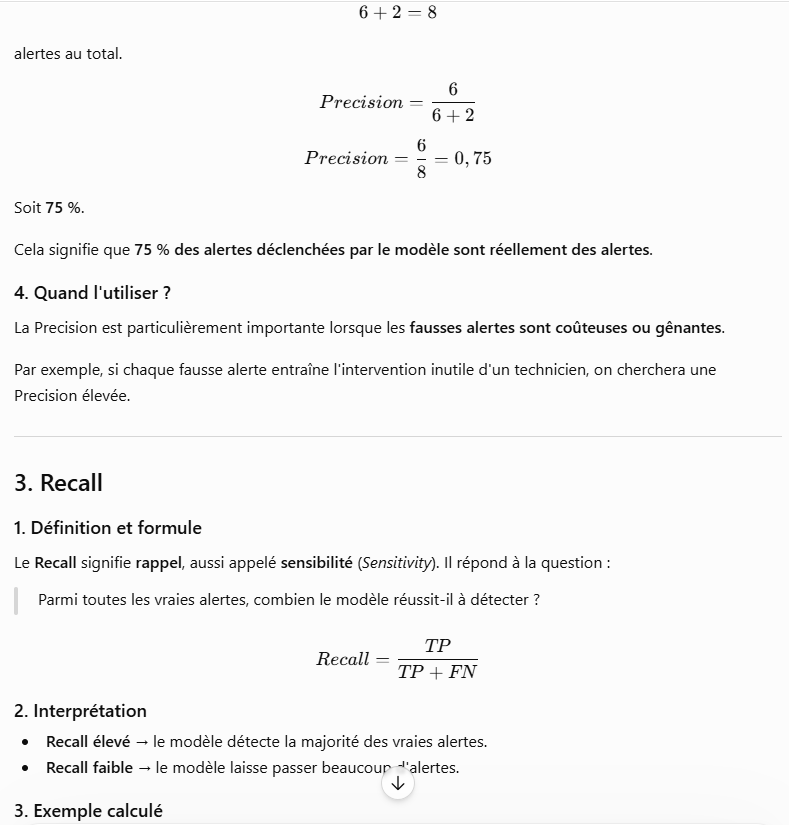
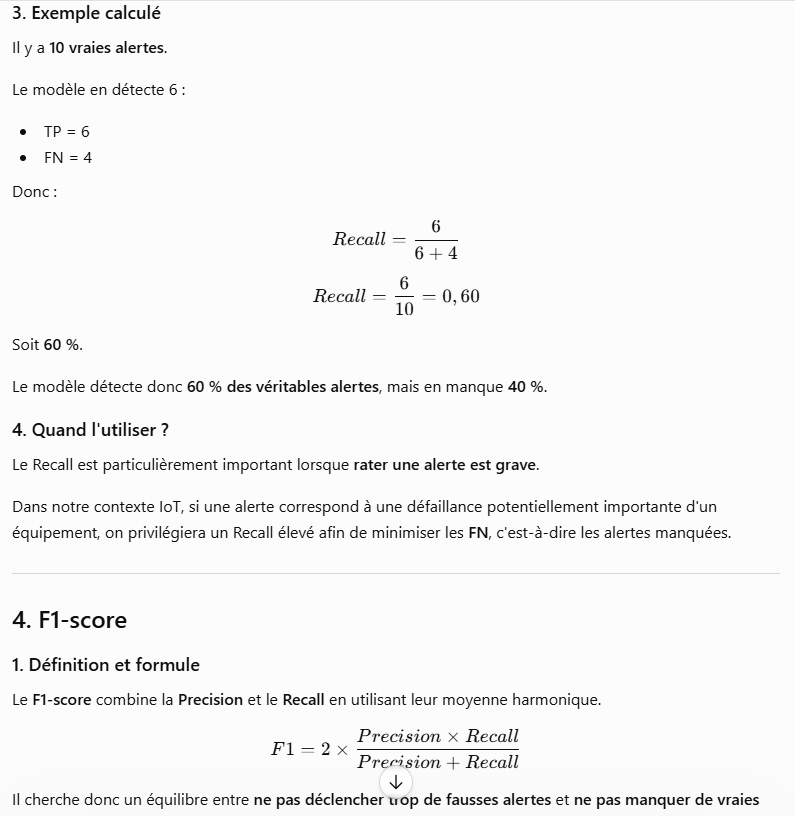
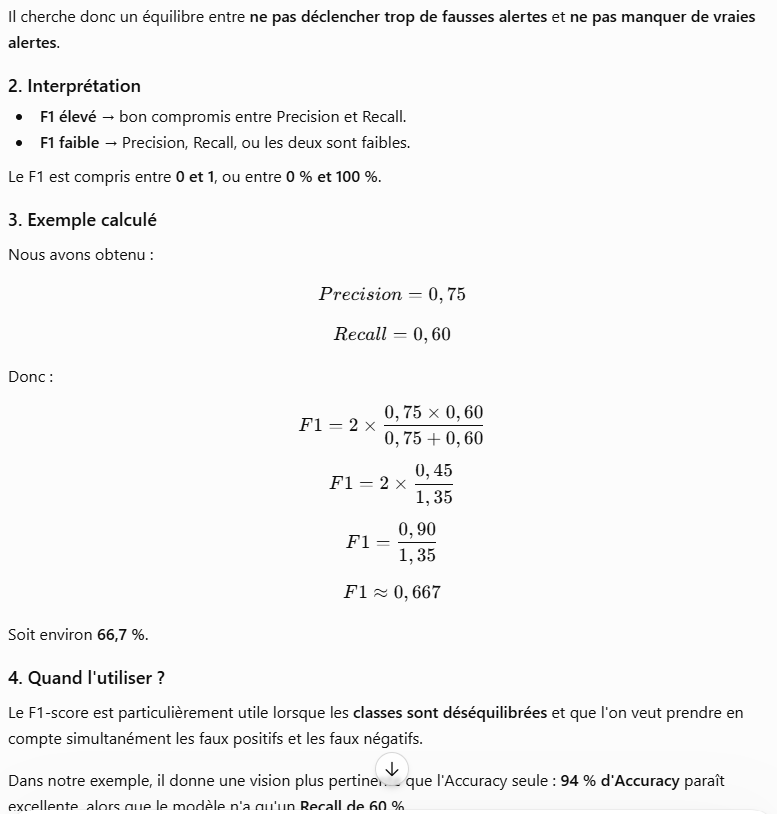
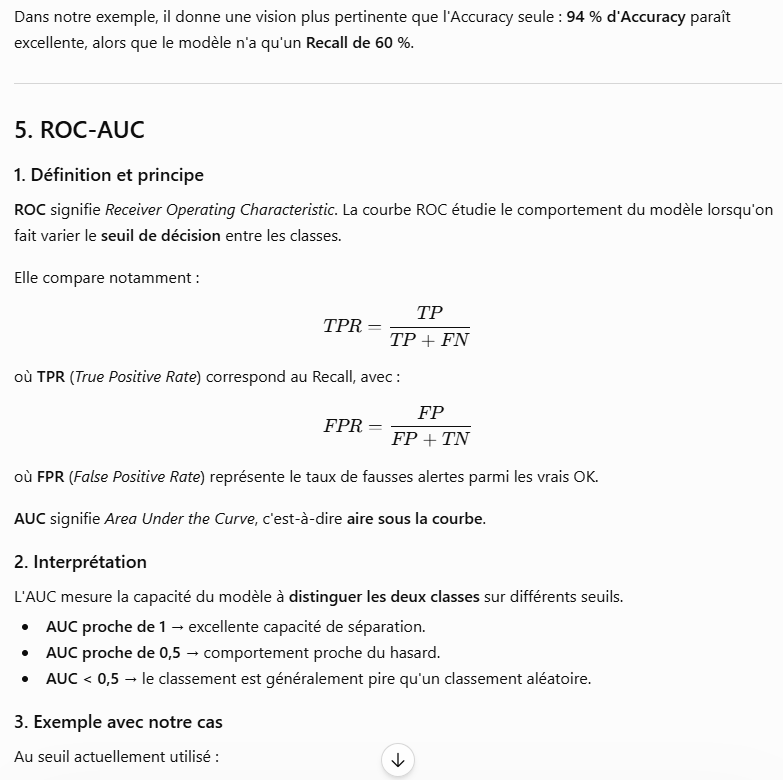
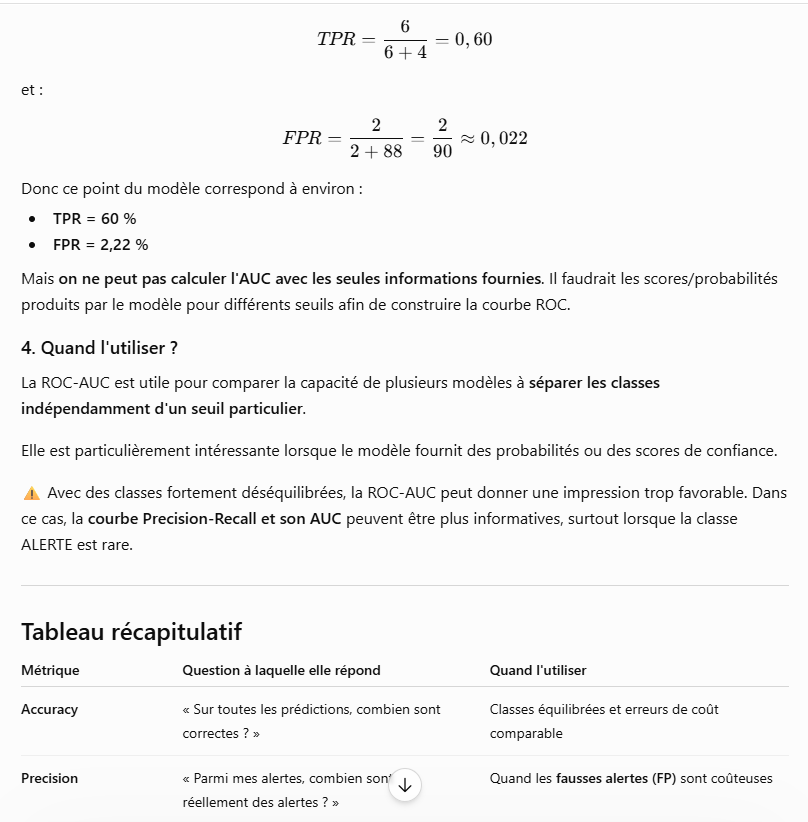
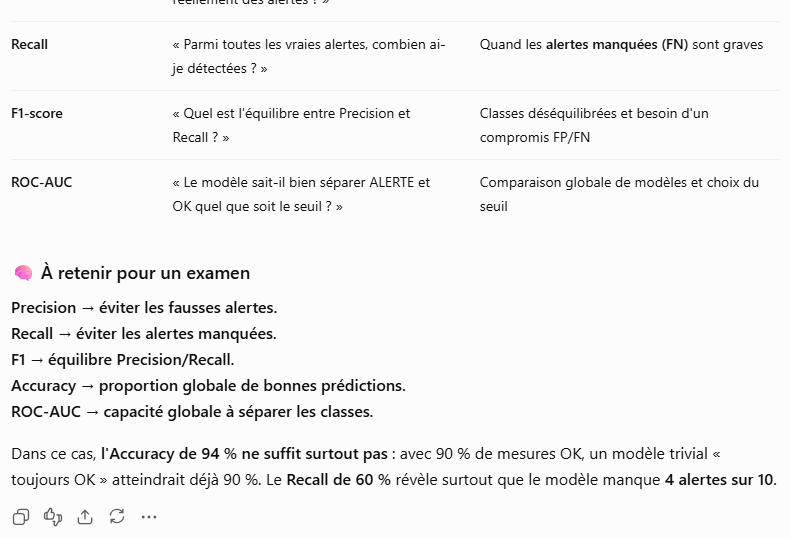

### 5. Explication des métriques de régression

*Valeurs attendues pour l'exemple : MAE = 15 ; MSE = 385 ; RMSE ≈ 19,62. La RMSE dépasse la MAE à cause de la seule grosse erreur (40).*

```text
# RÔLE
Tu es formateur en machine learning pour des analystes débutants.

# TÂCHE
Explique les métriques de régression suivantes : MAE, MSE et RMSE.

# INSTRUCTIONS
Pour chaque métrique, donne :
1. La définition, avec sa formule.
2. L'interprétation : unité, ce que signifie une valeur élevée ou faible.
3. Un exemple concret, calculé à partir du cas ci-dessous.
4. Le contexte dans lequel elle est particulièrement utile.

# CAS À UTILISER POUR LES EXEMPLES
Un modèle prédit la consommation énergétique d'un bâtiment sur 5 heures :
Valeurs réelles  : 200, 180, 250, 300, 220
Valeurs prédites : 210, 170, 240, 260, 225

# CONTRAINTES
- Vocabulaire simple ; explique chaque sigle.
- Montre le détail de chaque calcul.
- Explique pourquoi la RMSE pénalise davantage les grosses erreurs que la MAE.

# FORMAT DE SORTIE
Une section par métrique avec les 4 rubriques, puis un tableau récapitulatif :
Métrique | Unité | Sensibilité aux grosses erreurs | Quand l'utiliser
```

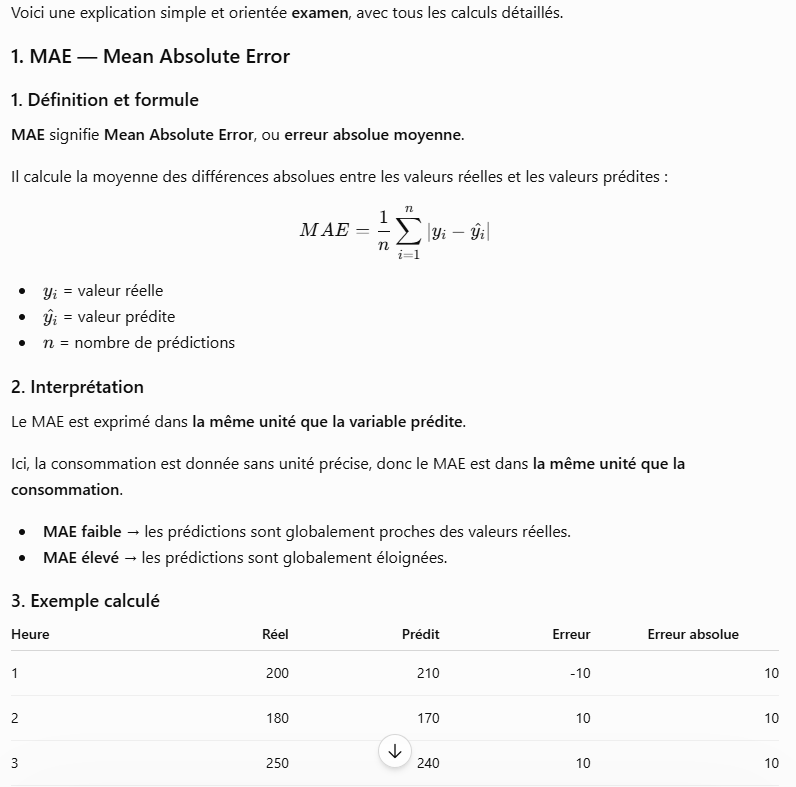
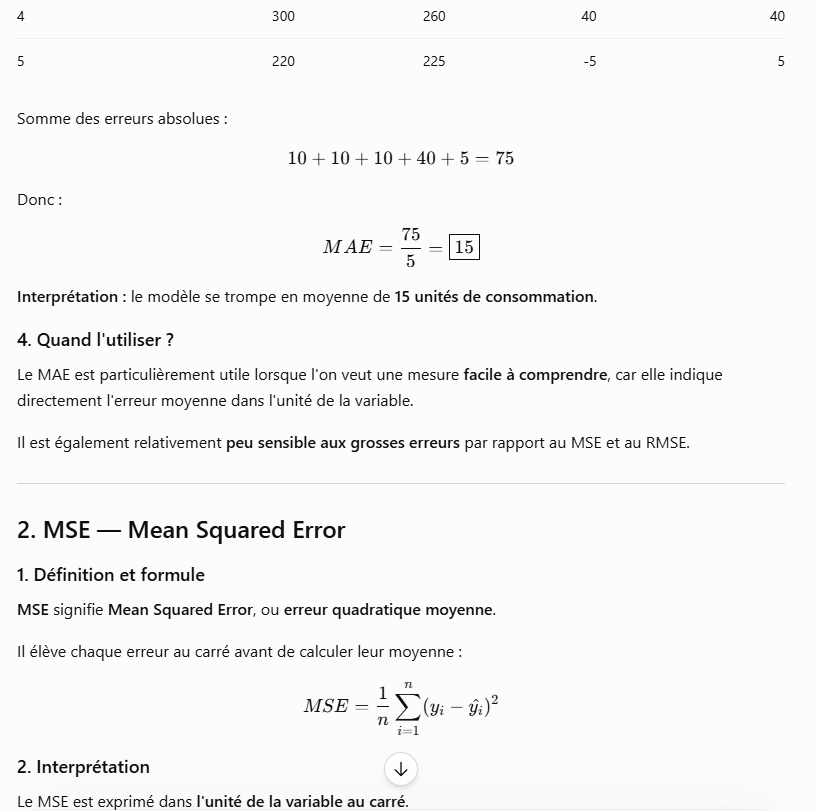
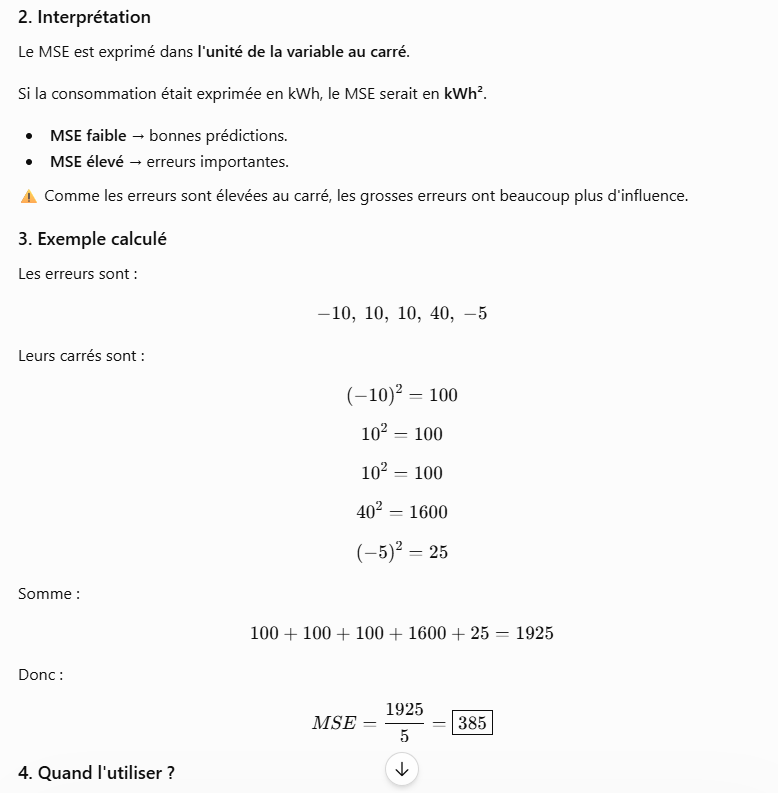
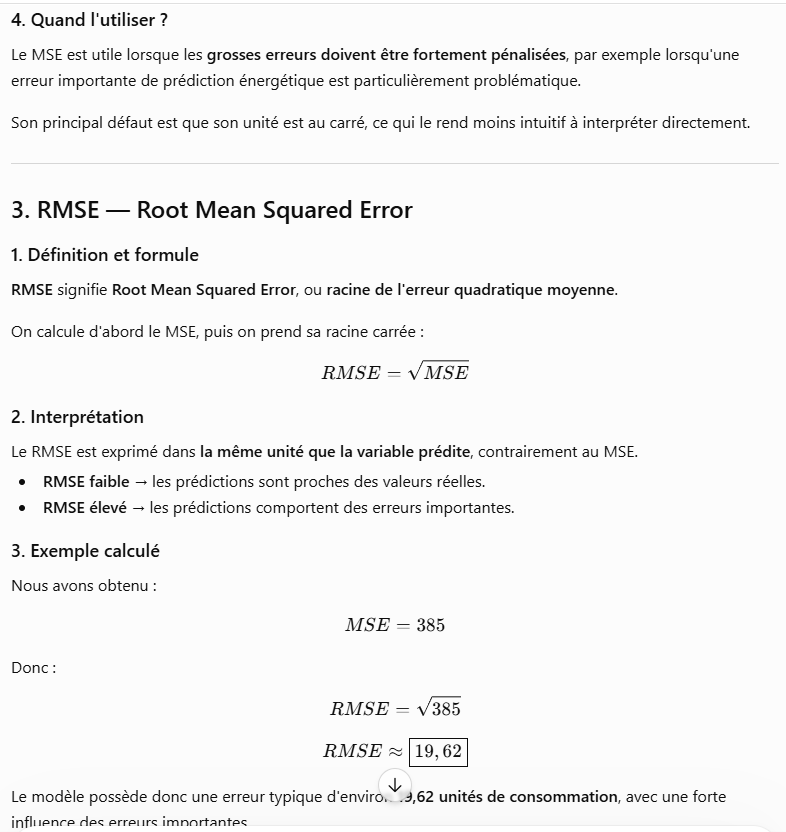
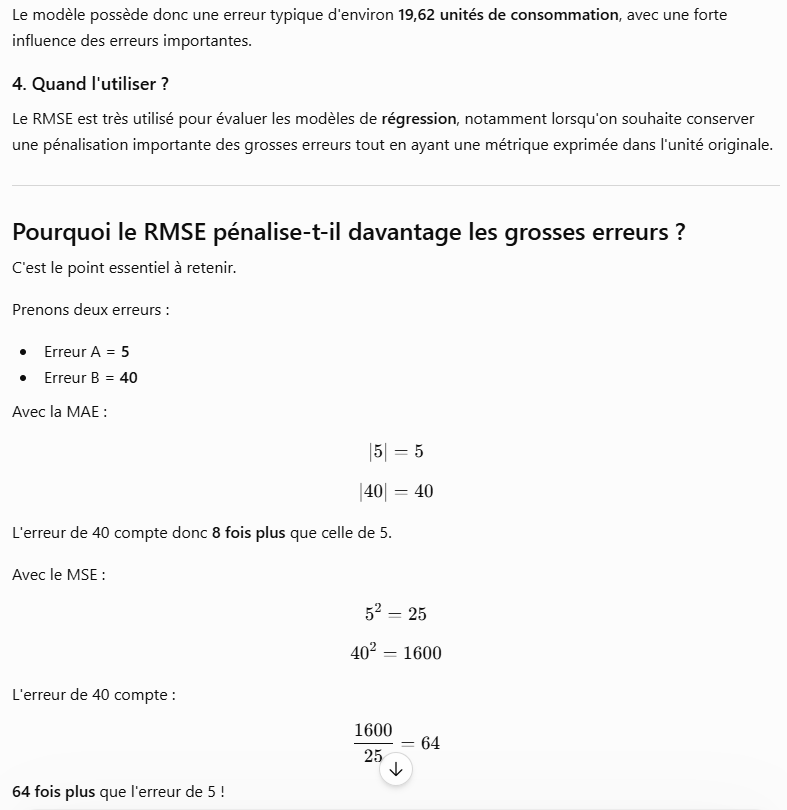
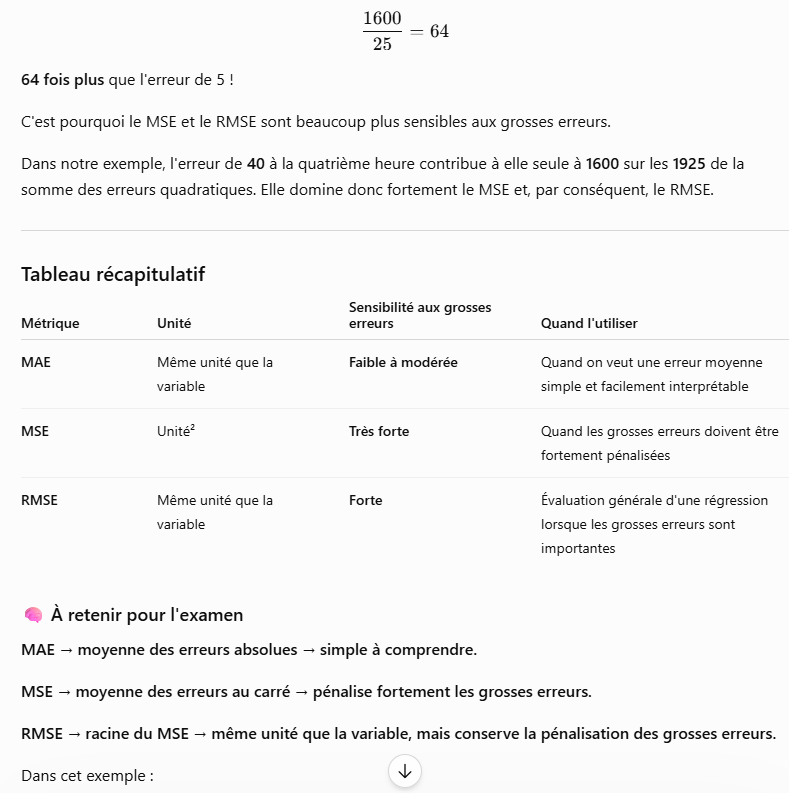
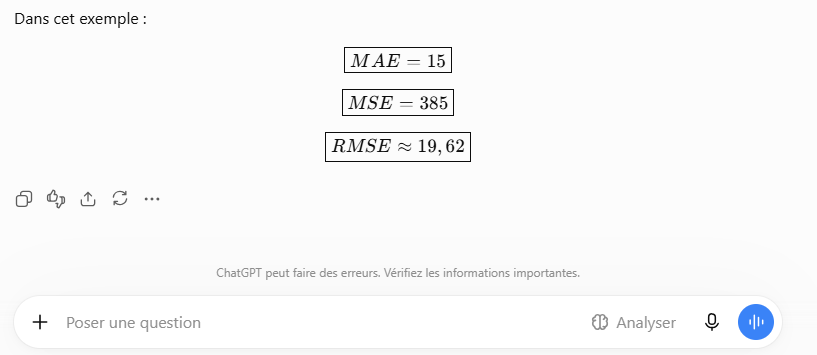

# Partie 7 - Prompt Engineering et RAG

Le **RAG** (*Retrieval-Augmented Generation*) consiste à fournir au LLM, dans le prompt, les passages de documents utiles pour répondre. Ici, l'étape de recherche (*retrieval*) est simulée : on fournit directement le document entier.

### 1. Le document

Politique de retour et de remboursement de ShopNet (document interne fictif, que ChatGPT ne peut donc pas connaître) : [data/politique_retours_shopnet.txt](data/politique_retours_shopnet.txt).

La question posée contient trois points :

| Point de la question | Réponse attendue | Source |
|---|---|---|
| Délai de retour | 10 jours après réception (30 jours pour les membres ShopNet+) | Article 1 |
| Frais de retour | Pris en charge par ShopNet si l'article est défectueux ou non conforme ; sinon, 1 500 FCFA déduits du remboursement | Article 4 |
| Articles soldés | **Information absente du document** | — |

### 2. Les trois prompts


#### Prompt A – Question sans le document

```text
Chez ShopNet, combien de jours ai-je pour retourner un article, qui paie les frais de retour, et puis-je retourner un article acheté pendant les soldes ?
```

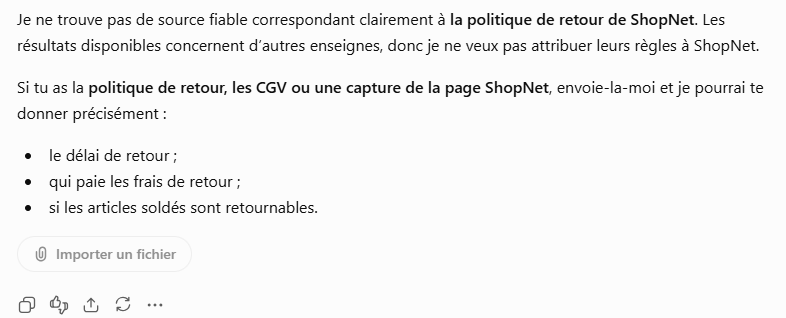

#### Prompt B – Question avec le document

```text
Voici un document :

<document>
Politique de retour et de remboursement – ShopNet
Version 3.2 – en vigueur depuis le 1er juillet 2026

Article 1 – Délai de retour
Le client dispose de 10 jours calendaires à compter de la date de réception de sa commande pour demander un retour. Ce délai est porté à 30 jours pour les membres du programme de fidélité ShopNet+.

Article 2 – Conditions de retour
L'article doit être retourné complet, dans son emballage d'origine et accompagné de sa facture. Les articles portés, lavés ou endommagés par le client ne sont pas repris.

Article 3 – Articles exclus
Ne peuvent pas être retournés : les produits d'hygiène dont l'emballage a été ouvert, les cartes cadeaux et les produits personnalisés à la demande du client.

Article 4 – Frais de retour
Si l'article est défectueux ou non conforme à la commande, les frais de retour sont pris en charge par ShopNet. Dans tous les autres cas, un forfait de 1 500 FCFA est déduit du montant remboursé.

Article 5 – Procédure
Le client fait sa demande depuis son espace client, rubrique « Mes commandes », ou via le chat de l'application. Une fois la demande acceptée, il dépose le colis dans l'un des points relais partenaires dans un délai de 7 jours.

Article 6 – Remboursement
Le remboursement est effectué dans un délai de 10 jours ouvrés après réception et contrôle de l'article, sur le moyen de paiement utilisé lors de la commande. Les commandes payées en espèces à la livraison sont remboursées par Wave ou Orange Money.
</document>

Question : Chez ShopNet, combien de jours ai-je pour retourner un article, qui paie les frais de retour, et puis-je retourner un article acheté pendant les soldes ?
```

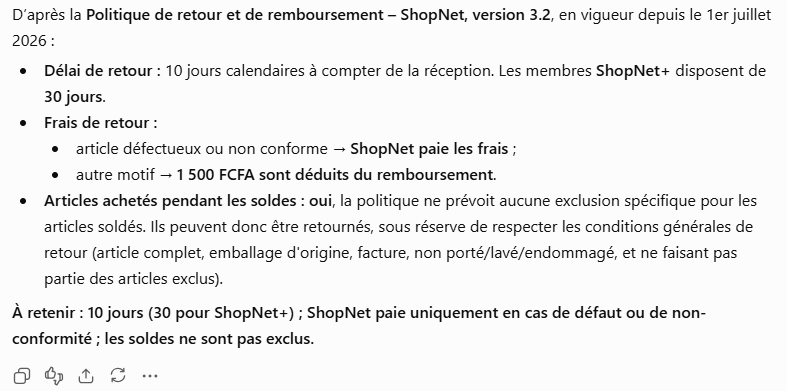